In [ ]:
#IMPORT RELEVANT LIBRARIES
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import platform
import psutil
import sys
import subprocess
import random
import time
from matplotlib.colors import LogNorm
from matplotlib.colors import Colormap

In [ ]:
# Setting up the constant seed for random initialization
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_all_seeds(42)

In [ ]:
# 1. Physics & Constants
L, h_ratio = 10.0, 1e-3
h = L * h_ratio
nu, mu, p_load = 0.3, 1e6, 1000
alpha = 1e-5
lam = 2*mu*nu/(1-2*nu)
beta = (3*lam + 2*mu) * alpha
q,k = 500, 0.2
Tref=0
T0=50

max_iterations_ADAMS=200
max_iteration_LBFGS=500

U_scale = h/(mu)
theta=q*h/(k)*beta

torch.set_default_dtype(torch.float64)

In [ ]:
# 2. Grid (51x31)
nx, ny = 51, 31
x1_grid = np.linspace(-L/2, L/2, nx)
x2_grid = np.linspace(0.0, h, ny)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

x_pde = torch.tensor(np.stack([X1.flatten()/L, X2.flatten()/h], axis=1), requires_grad=True)
x_bottom = torch.tensor(np.stack([x1_grid/L, np.zeros_like(x1_grid)], axis=1), requires_grad=True)
x_top = torch.tensor(np.stack([x1_grid/L, np.ones_like(x1_grid)], axis=1), requires_grad=True)


In [ ]:
#NEURAL NETWORK SETTING
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,40), nn.SiLU(),
            nn.Linear(40, 2)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
      return self.net(x)

# SIN activation if used, currently SiLU is used.
class Sin(nn.Module):
    def forward(self, x):
        return torch.sin(x)

In [ ]:
model = PINN()

print("===== SYSTEM INFORMATION =====")

# GPU
if torch.cuda.is_available():
    print("\n--- GPU ---")
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
    print("Total GPU Memory (GB):",
          torch.cuda.get_device_properties(0).total_memory / 1e9)
else:
    print("\nNo GPU available")

# CPU
print("\n--- CPU ---")
try:
    cpu_info = subprocess.check_output(
        "cat /proc/cpuinfo | grep 'model name' | head -1",
        shell=True
    ).decode()
    print(cpu_info.strip())
except:
    print("Processor:", platform.processor())

# RAM
print("\n--- RAM ---")
print("Total RAM (GB):", psutil.virtual_memory().total / 1e9)

# Software versions
print("\n--- SOFTWARE ---")
print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)

# Model parameters (make sure model is defined)
print("\n--- MODEL PARAMETERS ---")
try:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Total Parameters:", total_params)
    print("Trainable Parameters:", trainable_params)
except:
    print("Model not defined.")

print("\n===== END REPORT =====")





===== SYSTEM INFORMATION =====

No GPU available

--- CPU ---
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz

--- RAM ---
Total RAM (GB): 13.60582656

--- SOFTWARE ---
Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.10.0+cpu
CUDA Available: False
CUDA Version: None

--- MODEL PARAMETERS ---
Total Parameters: 202
Trainable Parameters: 202

===== END REPORT =====


In [ ]:
# 4. Loss Function
def loss_func(lambdas):
    def get_grad(u, x):
        return torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True, retain_graph=True)[0]

    v = model(x_pde)
    u1, u2 = v[:, 0:1]*U_scale, v[:, 1:2]*U_scale
    g1, g2 = get_grad(u1, x_pde), get_grad(u2, x_pde)

    u1_x, u1_y = g1[:, 0:1] * (1/L), g1[:, 1:2] * (1/h)
    u2_x, u2_y = g2[:, 0:1] * (1/L), g2[:, 1:2] * (1/h)

    u1_xx = get_grad(u1_x, x_pde)[:, 0:1]/L
    u1_yy = get_grad(u1_y, x_pde)[:, 1:2]/h
    u2_xx = get_grad(u2_x, x_pde)[:, 0:1]/L
    u2_yy = get_grad(u2_y, x_pde)[:, 1:2]/h
    div_u = u1_x + u2_y
    dg = get_grad(div_u, x_pde)

    div_x, div_y = dg[:, 0:1]/L, dg[:, 1:2]/h


    scale=h**2/U_scale
    res1 = scale * ((u1_xx + u1_yy) + 1/(1-2*nu) * div_x)
    res2 = scale * ((u2_xx + u2_yy) + 1/(1-2*nu) * div_y) + theta

    L_pde = torch.mean(res1**2) + torch.mean(res2**2)

    v_t = model(x_bottom)
    g1_t = get_grad(v_t[:, 0:1], x_bottom)
    g2_t = get_grad(v_t[:, 1:2], x_bottom)

    e11 = g1_t[:, 0:1] * (U_scale / L)
    e22 = g2_t[:, 1:2] * (U_scale / h)

    trace = e11 + e22

    char_stress = max(
        abs(p_load),
        beta * (abs(T0 - Tref) + q*h/k + 1e-6)
    )

    sigma22_b = ((2 * mu * e22 + lam * trace) - beta * T0)

    L_bot = torch.mean(model(x_bottom)**2)

    v_t = model(x_top)
    g1_t = get_grad(v_t[:, 0:1], x_top)
    g2_t = get_grad(v_t[:, 1:2], x_top)

    e11 = g1_t[:, 0:1] * (U_scale / L)
    e22 = g2_t[:, 1:2] * (U_scale / h)

    trace = e11 + e22

    char_stress = max(
        abs(p_load),
        beta * (abs(T0 - Tref) + q*h/k + 1e-6)
    )
    y_top = x_top[:, 1:2]
    T_top = T0-Tref - (q / k) * y_top * h
    deltaT = T_top - Tref

    sigma22 = ((2 * mu * e22 + lam * trace) - beta * deltaT)

    L_top = torch.mean( ((sigma22 + p_load) / char_stress )**2 )

    return L_pde, L_bot, L_top

In [ ]:
# Tracking containers
adam_loss_history = []
adam_L2_domain_error=[]
adam_sigma11_error=[]
adam_sigma22_error=[]
adam_sigma33_error=[]
adam_vm_error=[]
adam_lambdab = []
adam_lambdat = []
adam_eval_steps=[]
grad_history=[]
lp_history = []
lb_history = []
lt_history = []
sigma_smoothness_history=[]

# Domain-wide L2 error utilities

Nx_eval, Ny_eval = 80, 80
xg = torch.linspace(-0.5, 0.5, Nx_eval)
yg = torch.linspace(0.0, 1.0, Ny_eval)
Xg, Yg = torch.meshgrid(xg, yg, indexing="ij")
x_eval = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1)

def exact_solution(x):
    y_norm = x[:,1:2]
    y = y_norm * h

    deltaT = (T0 - Tref) - (q / k) * y

    denom = lam + 2*mu

    linear_part  = (-p_load + beta * (T0 - Tref)) / denom * y
    quadratic_part = - (beta * q / (k * denom)) * (y**2 / 2)

    u2 = linear_part + quadratic_part
    u1 = torch.zeros_like(y)

    return torch.cat([u1, u2], dim=1)

def relative_L2_error_domain():
    with torch.no_grad():
        u_pred = model(x_eval) * U_scale
        u_exact = exact_solution(x_eval)

        return (torch.norm(u_pred - u_exact) /
                torch.norm(u_exact)).item()


# Stress evaluation (PINN vs Exact)

def compute_stress_pinn(x):
    x = x.clone().requires_grad_(True)
    v = model(x) * U_scale
    u1, u2 = v[:, 0:1], v[:, 1:2]

    g1 = torch.autograd.grad(u1.sum(), x, create_graph=True)[0]
    g2 = torch.autograd.grad(u2.sum(), x, create_graph=True)[0]

    exx = g1[:, 0:1] * (1 / L)
    eyy = g2[:, 1:2] * (1 / h)

    y_phys = x[:, 1:2] * h
    deltaT = (T0 - (q / k) * y_phys) - Tref

    sigma11 = (lam + 2*mu) * exx + lam * eyy - beta * deltaT
    sigma22 = (lam + 2*mu) * eyy + lam * exx - deltaT * beta
    sigma33 = lam * (exx + eyy) - beta * deltaT
    return sigma11, sigma22, sigma33


def exact_stress(x):
    y_norm = x[:, 1:2]
    y_phys = y_norm * h

    deltaT = (T0 - Tref) - (q / k) * y_phys

    denom = lam + 2*mu

    eyy = (-p_load + beta * deltaT) / denom

    sigma22 = -p_load * torch.ones_like(y_norm)

    sigma11 = lam * eyy - beta * deltaT
    sigma33 = lam * (0 + eyy) - beta * deltaT

    return sigma11, sigma22, sigma33

def relative_L2_error_stress_domain():
    x = x_eval.clone().detach().requires_grad_(True)

    s11_p, s22_p, s33_p = compute_stress_pinn(x)
    s11_e, s22_e, s33_e = exact_stress(x)

    def calc_vm(s1, s2, s3):
        return torch.sqrt(0.5 * ((s1 - s2)**2 + (s2 - s3)**2 + (s3 - s1)**2))

    vm_p = calc_vm(s11_p, s22_p, s33_p)
    vm_e = calc_vm(s11_e, s22_e, s33_e)

    err_vm = torch.norm(vm_p - vm_e) / torch.norm(vm_e)
    err_s11 = torch.norm(s11_p - s11_e)/torch.norm(s11_e)
    err_s22 = torch.norm(s22_p - s22_e)/torch.norm(s22_e)
    return err_s11.item(), err_s22.item(),err_vm.item()

def grad_stats(loss, model):
    grads = torch.autograd.grad(
        loss,
        model.parameters(),
        retain_graph=True,
        allow_unused=True
    )
    grads = torch.cat([g.reshape(-1) for g in grads if g is not None])
    return grads.abs().mean(), grads.abs().max()

def adaptive_weights(lp, lb, lt, model, eps=1e-12):
    mean_lp, max_lp = grad_stats(lp, model)
    mean_lb, _      = grad_stats(lb, model)
    mean_lt, max_lt     = grad_stats(lt, model)

    lambda_b = (mean_lp / (mean_lb + eps)).detach()
    lambda_t = (mean_lp / (mean_lt + eps)).detach()

    return lambda_b, lambda_t



def compute_grad_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item()**2
    total_norm = total_norm**0.5
    return total_norm

start_time = time.time()

# Phase 1: Adam Warmup
print("Optimization")

optimizer_adam = torch.optim.Adam(model.parameters(), lr=8e-3)

for i in range(max_iterations_ADAMS):
    optimizer_adam.zero_grad()
    lp, lb, lt = loss_func(None)
    lambda_b, lambda_t = adaptive_weights(lp, lb, lt, model)

    loss = (lp + lambda_b*lb + lambda_t*lt)

    adam_lambdab.append(lambda_b.item())
    adam_lambdat.append(lambda_t.item())

    err_s11, err_s22, err_vm = relative_L2_error_stress_domain()
    with torch.enable_grad():
        x_s = x_eval.clone().detach().requires_grad_(True)

        s11_s, s22_s, s33_s = compute_stress_pinn(x_s)

        vm_s = torch.sqrt(0.5 * ((s11_s - s22_s)**2 + (s22_s - s33_s)**2 + (s33_s - s11_s)**2))

        s22_g = torch.autograd.grad(s22_s, x_s, torch.ones_like(s22_s))[0]

        mag = torch.sqrt((s22_g[:, 0:1]/L)**2 + (s22_g[:, 1:2]/h)**2).mean().item()
        sigma_smoothness_history.append(mag)


    adam_sigma11_error.append(err_s11)
    adam_sigma22_error.append(err_s22)
    adam_vm_error.append(err_vm)

    rel_err_domain = relative_L2_error_domain()
    adam_L2_domain_error.append(rel_err_domain)

    adam_eval_steps.append(i)
    lp_history.append(lp.item())
    lb_history.append(lb.item())
    lt_history.append(lt.item())

    loss.backward()

    grad_norm = compute_grad_norm(model)
    grad_history.append(grad_norm)

    optimizer_adam.step()
    adam_loss_history.append(loss.item())

    if i % 25 == 0:
       print(f"Eval {i:4d} | lp: {lp:.2e} | lb: {lb:.2e} | lt: {lt:.2e}")
       print(f"Eval {i:4d} | Error u: {rel_err_domain:.2e}| Error sigma11 : {err_s11:.2e} | Error sigma22 : {err_s22:.2e} |Error vM : {err_vm:.2e} | lambda_b: {lambda_b:.2e} | lambda_t: {lambda_t:.2e}")
       print(f"Step {i} | Loss: {loss.item():.2e}")

    if i > 50 and (rel_err_domain < 1e-2 or err_s22 < 1e-3 or abs((adam_L2_domain_error[i] - adam_L2_domain_error[i-1]) / (adam_L2_domain_error[i-1] + 1e-10)) < 1e-6):
      print(f"Stopping at {i}: Early Stopping Adam Optimiser, Converged or No meaning ful progress")
      print(f"Eval {i:4d} | lp: {lp:.2e} | lb: {lb:.2e} | lt: {lt:.2e}")
      print(f"Eval {i:4d} | Error u: {rel_err_domain:.2e}| Error sigma11 : {err_s11:.2e} | Error sigma22 : {err_s22:.2e} |Error vM : {err_vm:.2e} | lambda_b: {lambda_b:.2e} | lambda_t: {lambda_t:.2e}")
      print(f"Step {i} | Loss: {loss.item():.2e}")
      print(f"consective run error: {abs((adam_L2_domain_error[i] - adam_L2_domain_error[i-1]) / (adam_L2_domain_error[i-1] + 1e-10))}")
      break

print(f"Adam phase finished after {i+1} steps")


# Phase 2: L-BFGS refinement

print("\nPhase 2: L-BFGS refinement ...")

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    max_eval=None,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer_lbfgs.zero_grad()

    lp, lb, lt = loss_func(None)

    total_loss = lp + lambda_b * lb + lambda_t * lt

    total_loss.backward()
    return total_loss

lbfgs_loss_history = []
lbfgs_u_error_history = []
lbfgs_s11_error_history = []
lbfgs_s22_error_history = []
lbfgs_s33_error_history = []
lbfgs_vm_error_history = []

prev_loss = float('inf')

for j in range(max_iteration_LBFGS):

    def wrapped_closure():
        return closure()

    current_loss = optimizer_lbfgs.step(wrapped_closure)

    grad_norm = compute_grad_norm(model)
    grad_history.append(grad_norm)

    lp_eval, lb_eval, lt_eval = loss_func(None)

    lp_history.append(lp_eval.item())
    lb_history.append(lb_eval.item())
    lt_history.append(lt_eval.item())

    lambda_b, lambda_t=adaptive_weights(lp_eval, lb_eval, lt_eval, model)

    eval_loss = lp_eval + lambda_b * lb_eval + lambda_t * lt_eval

    with torch.enable_grad():
        x_s = x_eval.clone().detach().requires_grad_(True)
        s11, s22, s33 = compute_stress_pinn(x_s)

        vm = torch.sqrt(0.5 * ((s11 - s22)**2 + (s22 - s33)**2 + (s33 - s11)**2))

        s22_g = torch.autograd.grad(s22, x_s, torch.ones_like(s22))[0]

        mag = torch.sqrt((s22_g[:, 0:1]/L)**2 + (s22_g[:, 1:2]/h)**2).mean().item()
        sigma_smoothness_history.append(mag)


    u_err = relative_L2_error_domain()
    s11_err, s22_err, vm_err = relative_L2_error_stress_domain()

    lbfgs_loss_history.append(eval_loss.item())
    lbfgs_u_error_history.append(u_err)
    lbfgs_s11_error_history.append(s11_err)
    lbfgs_s22_error_history.append(s22_err)
    lbfgs_vm_error_history.append(vm_err)

    print(f"[LBFGS {j:3d}]  loss: {eval_loss.item():.4e}   "
          f"u_err: {u_err:.2e} |  sigma11: {s11_err:.2e} |  sigma22: {s22_err:.2e} |  VM: {vm_err:.2e}")

    if (u_err < 1e-5 or s22_err < 5e-6) and u_err < 1e-2 and s22_err < 1e-3:
        print("Early stopping in LBFGS: target accuracy reached")
        break
    if abs(prev_loss - eval_loss.item()) < 1e-30:
        print("Early stopping in LBFGS: loss stalled")
        break
    prev_loss = eval_loss.item()

print("L-BFGS phase finished")


full_loss_history = adam_loss_history + lbfgs_loss_history

full_lp = lp_history
full_lb = lb_history
full_lt = lt_history

full_u_error = adam_L2_domain_error+ lbfgs_u_error_history
full_sigma11_error = adam_sigma11_error+ lbfgs_s11_error_history
full_sigma22_error = adam_sigma22_error+ lbfgs_s22_error_history
full_vm_error = adam_vm_error+ lbfgs_vm_error_history

total_iterations = np.arange(len(full_loss_history))
transition_idx = len(adam_loss_history)


end_time = time.time()
total_time = end_time - start_time

print(f"\nTotal training time: {total_time:.2f} seconds")
print(f"Final u L2 error:   {u_err:.2e}")
print(f"Final sigma11 error:     {s11_err:.2e}")
print(f"Final sigma22 error:     {s22_err:.2e}")
print(f"Final VM error:     {vm_err:.2e}")


Optimization
Eval    0 | lp: 2.64e+06 | lb: 3.09e-03 | lt: 1.65e-02
Eval    0 | Error u: 1.00e+00| Error sigma11 : 3.53e-01 | Error sigma22 : 1.52e+00 |Error vM : 9.99e-01 | lambda_b: 1.15e+05 | lambda_t: 1.56e+07
Step 0 | Loss: 2.90e+06
Eval   25 | lp: 2.64e+06 | lb: 1.69e-05 | lt: 1.64e-02
Eval   25 | Error u: 9.99e-01| Error sigma11 : 3.52e-01 | Error sigma22 : 1.51e+00 |Error vM : 9.99e-01 | lambda_b: 1.97e+06 | lambda_t: 2.48e+07
Step 25 | Loss: 3.04e+06
Eval   50 | lp: 2.63e+06 | lb: 1.46e-05 | lt: 1.58e-02
Eval   50 | Error u: 9.92e-01| Error sigma11 : 3.49e-01 | Error sigma22 : 1.50e+00 |Error vM : 9.92e-01 | lambda_b: 3.48e+06 | lambda_t: 3.85e+07
Step 50 | Loss: 3.24e+06
Eval   75 | lp: 2.62e+06 | lb: 8.72e-05 | lt: 1.45e-02
Eval   75 | Error u: 9.75e-01| Error sigma11 : 3.43e-01 | Error sigma22 : 1.47e+00 |Error vM : 9.74e-01 | lambda_b: 4.28e+06 | lambda_t: 4.99e+07
Step 75 | Loss: 3.35e+06
Eval  100 | lp: 2.60e+06 | lb: 1.25e-04 | lt: 1.22e-02
Eval  100 | Error u: 9.41e-01

In [ ]:
def compute_energy_error():
    x = x_eval.clone().detach().requires_grad_(True)
    u = model(x) * U_scale
    u1, u2 = u[:, 0:1], u[:, 1:2]

    g1 = torch.autograd.grad(u1.sum(), x, create_graph=True)[0]
    g2 = torch.autograd.grad(u2.sum(), x, create_graph=True)[0]

    exx_total_p = g1[:, 0:1] * (1.0 / L)
    eyy_total_p = g2[:, 1:2] * (1.0 / h)
    exy_p = 0.5 * (g1[:, 1:2] * (1.0 / h) + g2[:, 0:1] * (1.0 / L))

    y_phys = x[:, 1:2] * h
    deltaT = (T0 - (q/k) * y_phys) - Tref
    eps_thermal = alpha * deltaT

    exx_elas_p = exx_total_p - eps_thermal
    eyy_elas_p = eyy_total_p - eps_thermal
    exy_elas_p = exy_p

    eyy_total_e = (-p_load + beta * deltaT) / (lam + 2*mu)
    exx_total_e = torch.zeros_like(eyy_total_e)
    exy_total_e = torch.zeros_like(eyy_total_e)

    exx_elas_e = exx_total_e - eps_thermal
    eyy_elas_e = eyy_total_e - eps_thermal
    exy_elas_e = exy_total_e

    def elastic_energy_density(e11, e22, e12):
        return 0.5 * (
            (lam + 2*mu) * (e11**2 + e22**2) +
            2*lam * e11 * e22 +
            4*mu * (e12**2)
        )

    pinn_energy_density = elastic_energy_density(
        exx_elas_p,
        eyy_elas_p,
        exy_elas_p
    )

    exact_energy_density = elastic_energy_density(
        exx_elas_e, eyy_elas_e, exy_elas_e
    )

    dx_phys = L / (Nx_eval - 1) if Nx_eval > 1 else L
    dy_phys = h / (Ny_eval - 1) if Ny_eval > 1 else h
    cell_area = dx_phys * dy_phys

    integral_error = torch.sum(abs(pinn_energy_density-exact_energy_density)) * cell_area
    integral_exact = torch.sum(exact_energy_density) * cell_area + 1e-20

    rel_energy_error = torch.sqrt(integral_error / integral_exact)
    print(f"Global relative strain energy error: {rel_energy_error.item():.3e}")
    return rel_energy_error.item(), exact_energy_density.detach().cpu().numpy().reshape(Nx_eval, Ny_eval)


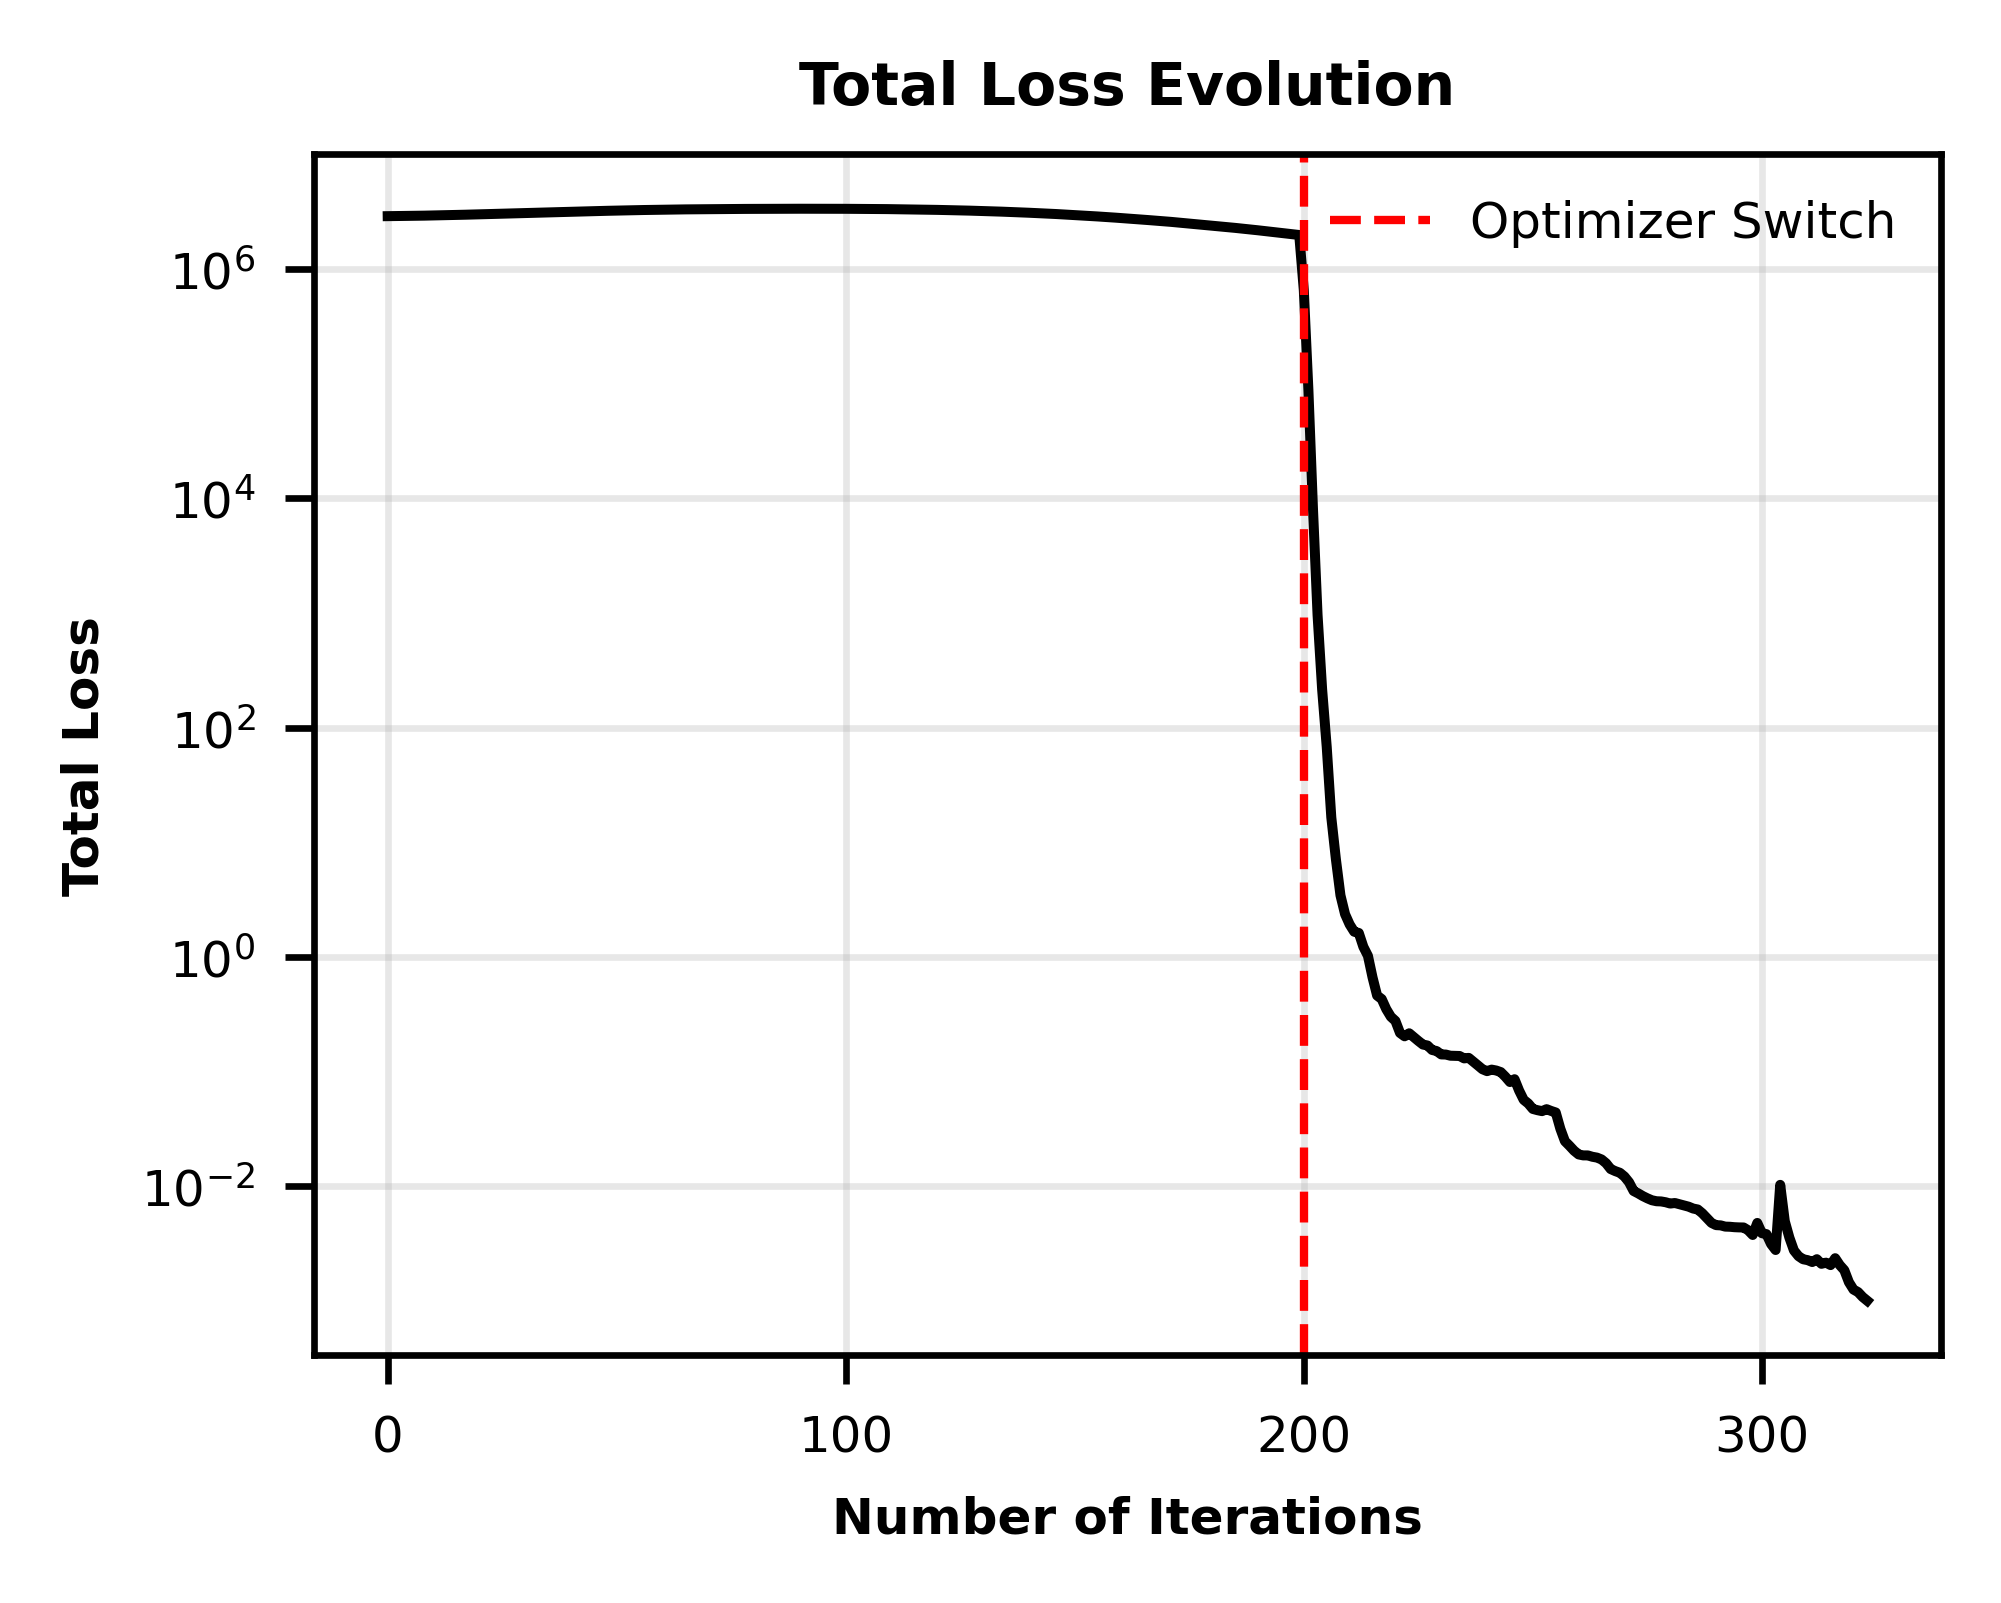

In [ ]:

transition_idx = len(adam_loss_history)

# 1. Total Loss Convergence

plt.figure(figsize=(3.5, 2.6), dpi=600)
plt.semilogy(full_loss_history, color='black', linewidth=1.2)
plt.axvline(x=transition_idx, color='red', linestyle='--',
            linewidth=1.0, label='Optimizer Switch')
plt.xlabel("Number of Iterations", fontsize=6, fontweight='bold')
plt.ylabel("Total Loss", fontsize=6, fontweight='bold')
plt.title("Total Loss Evolution", fontsize=7, fontweight='bold')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.legend(fontsize=6, frameon=False)
plt.grid(True, which="both", alpha=0.3)
plt.show()




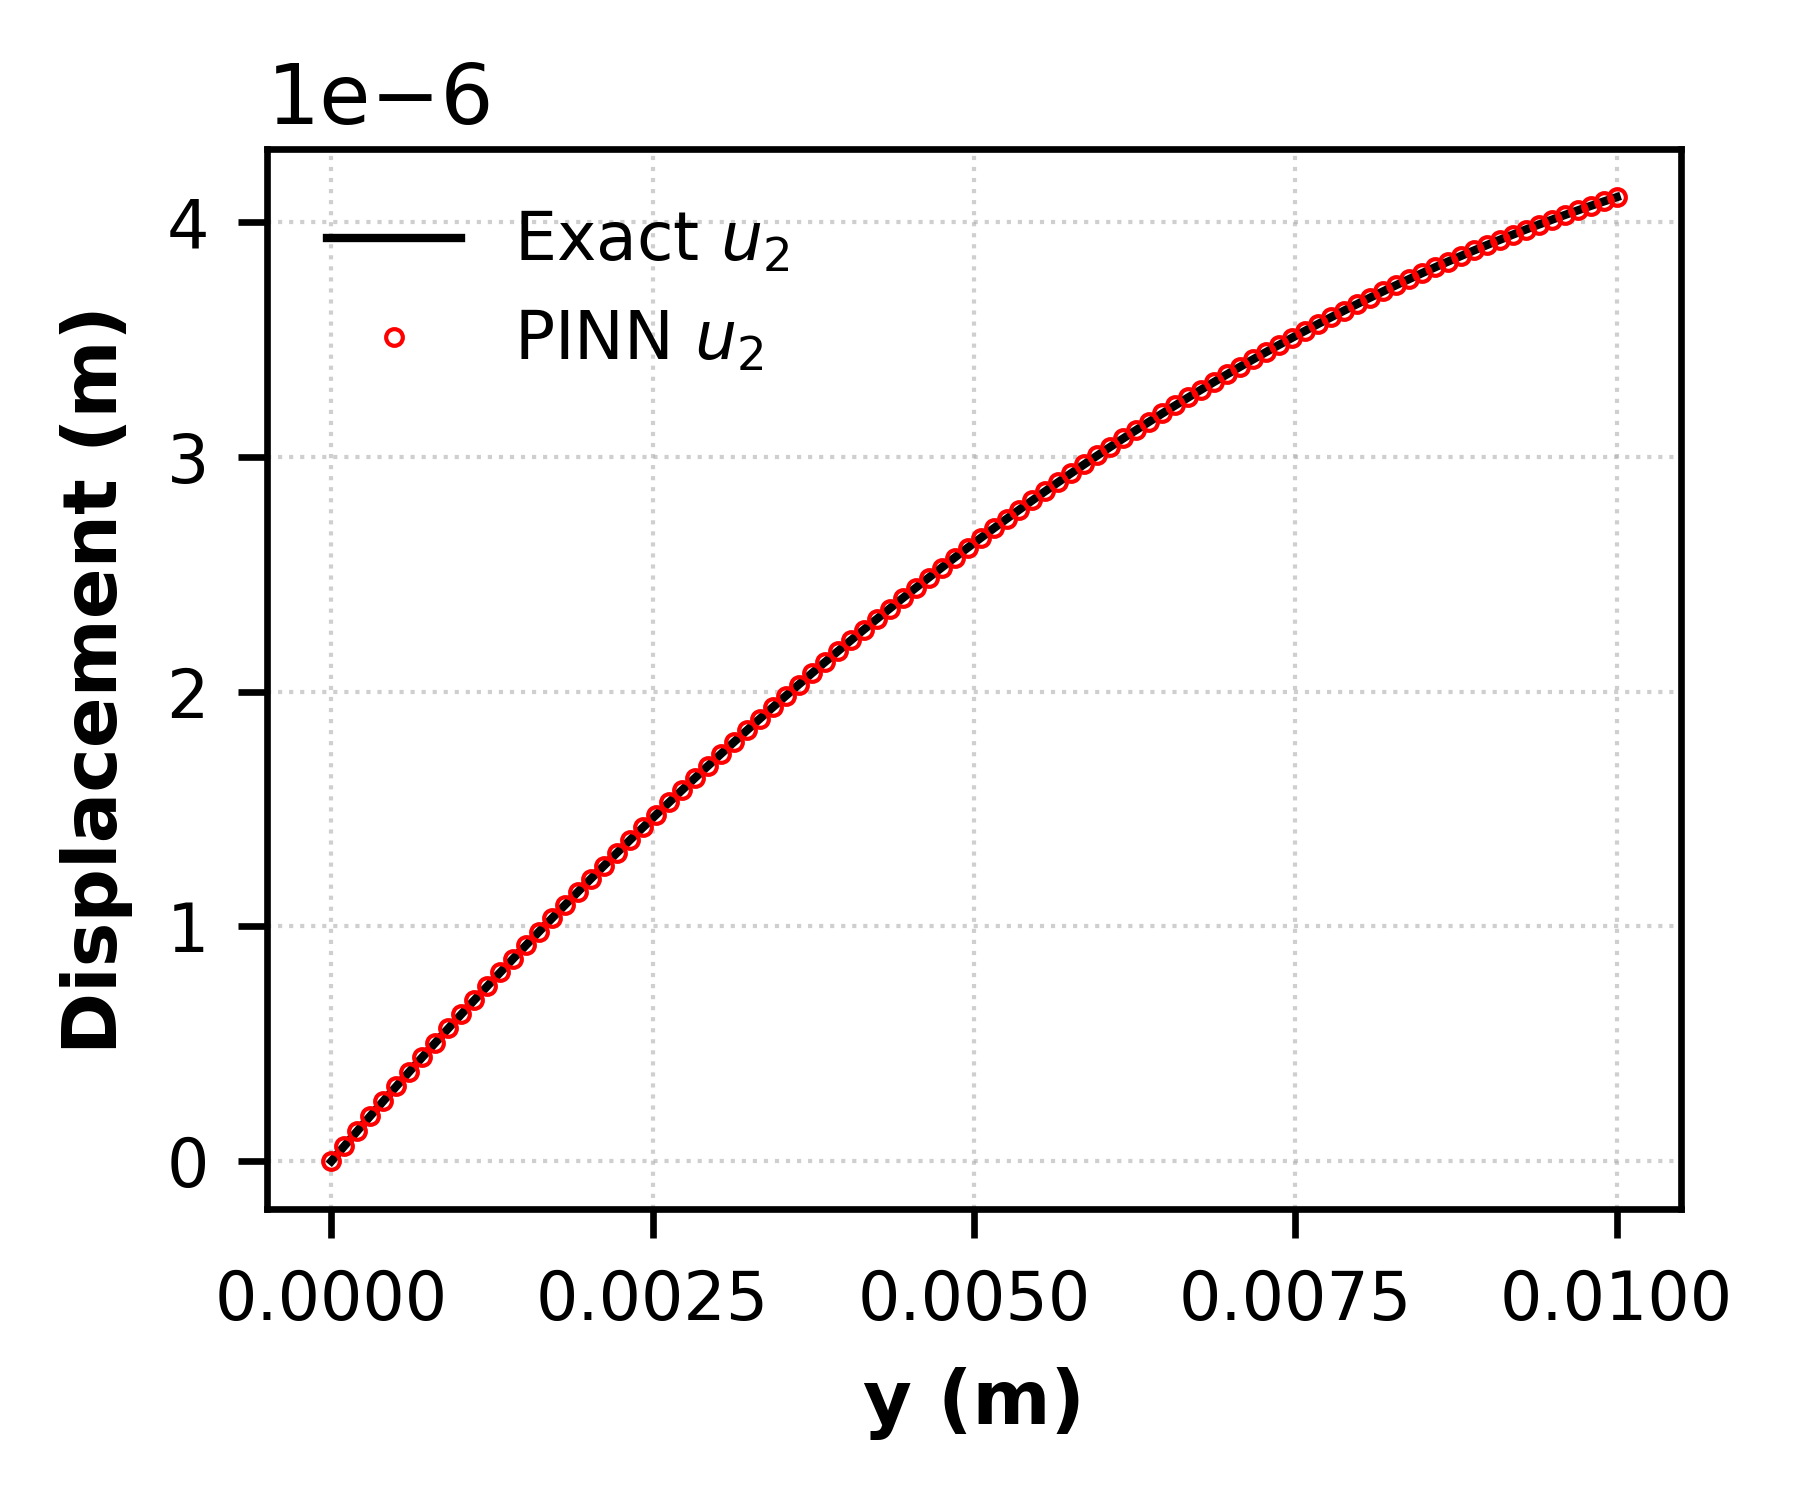

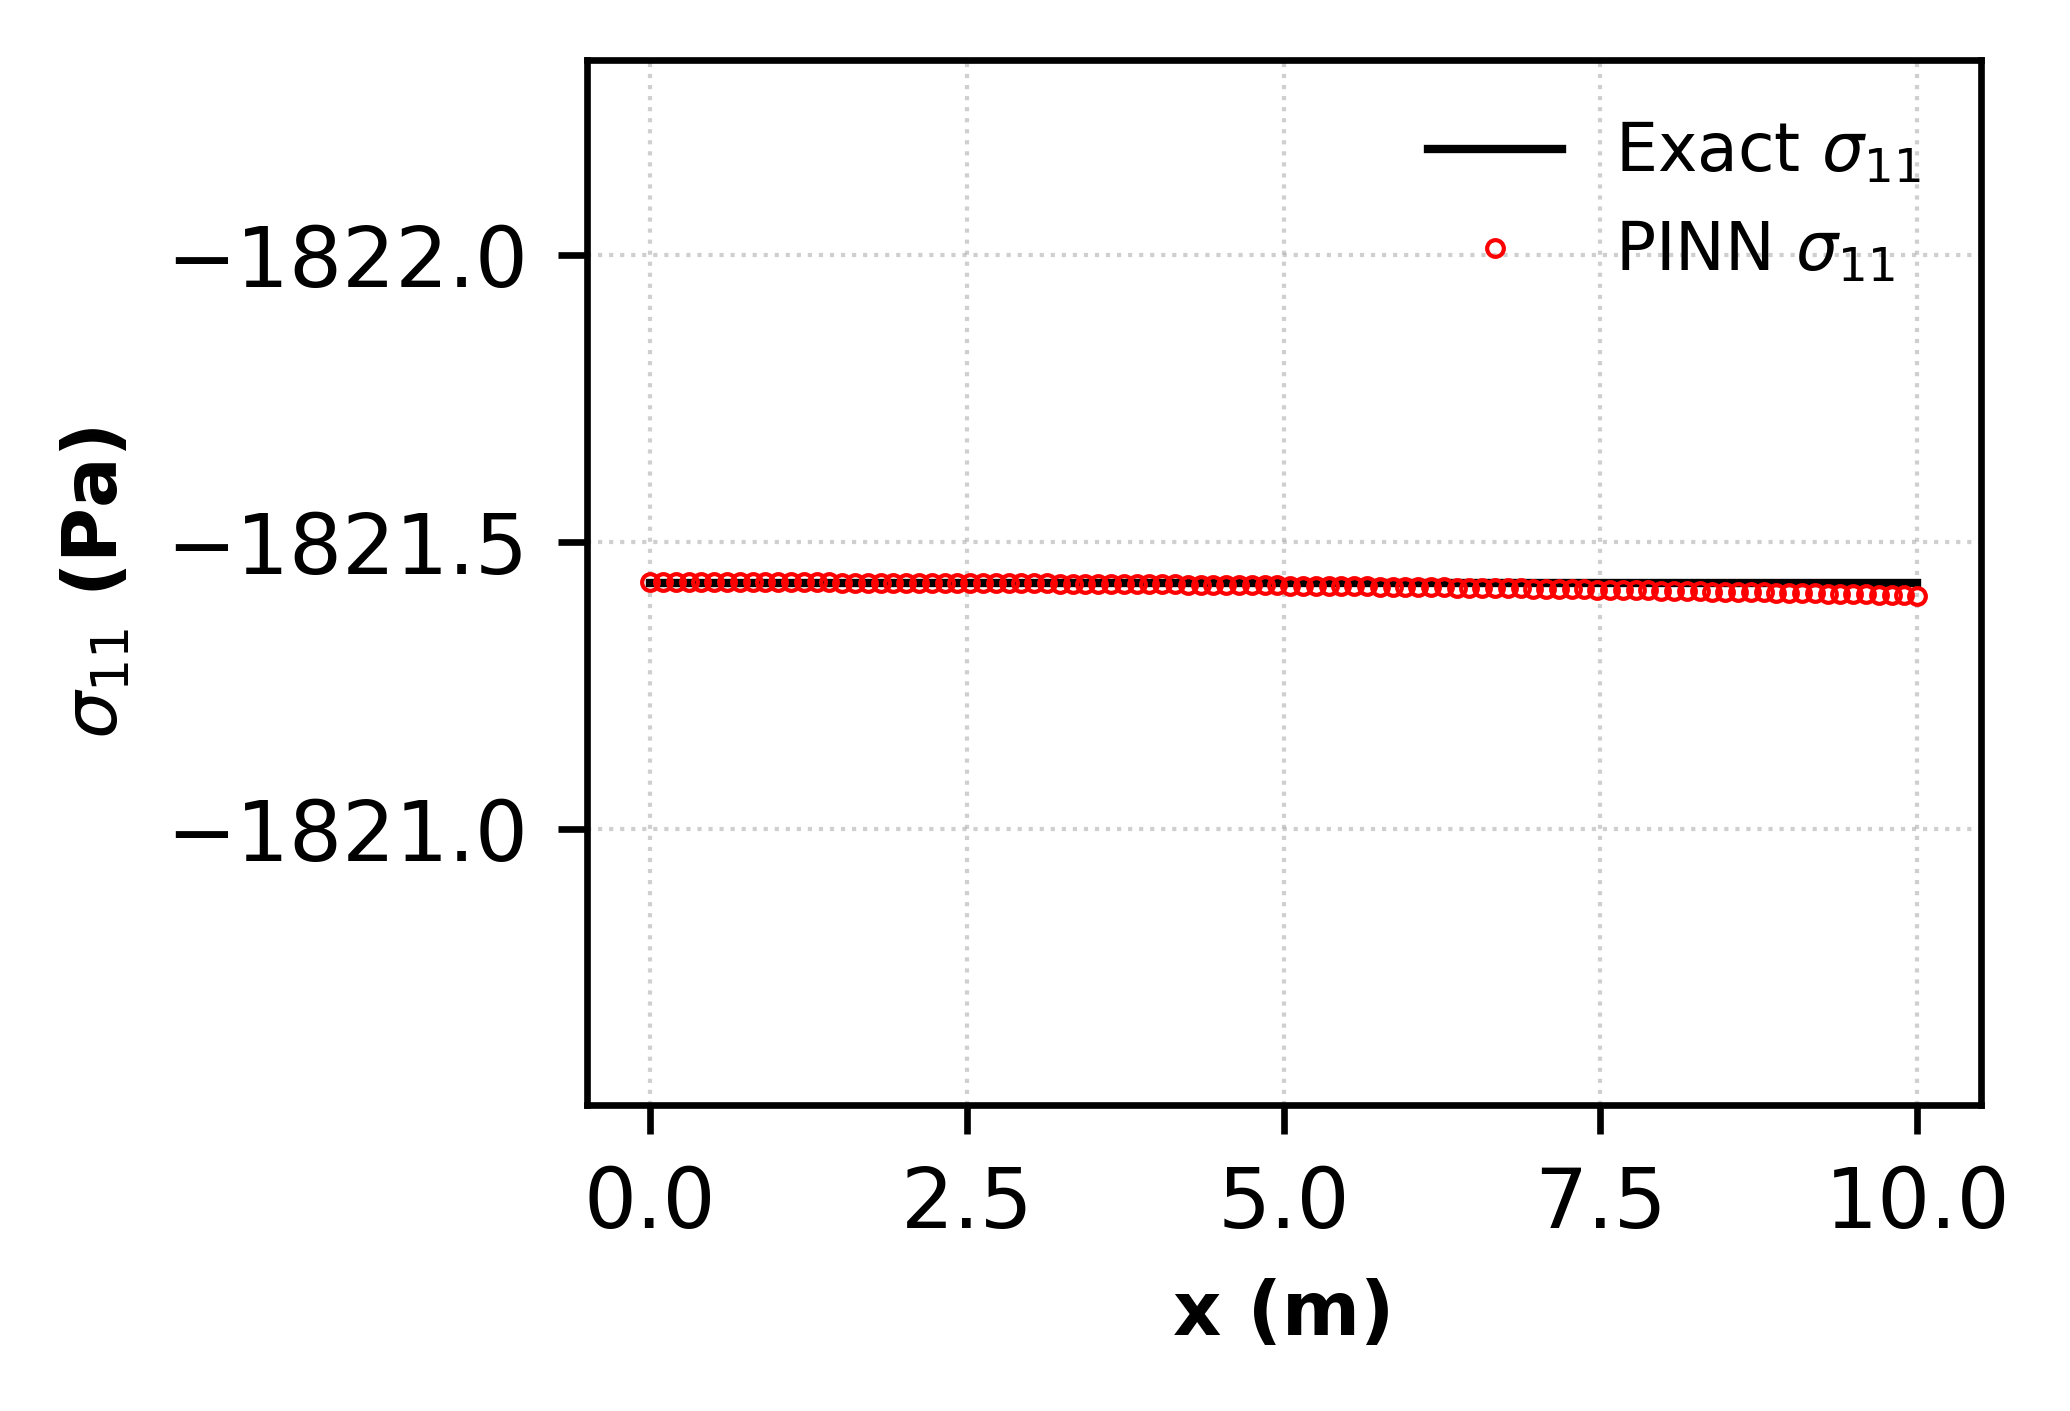

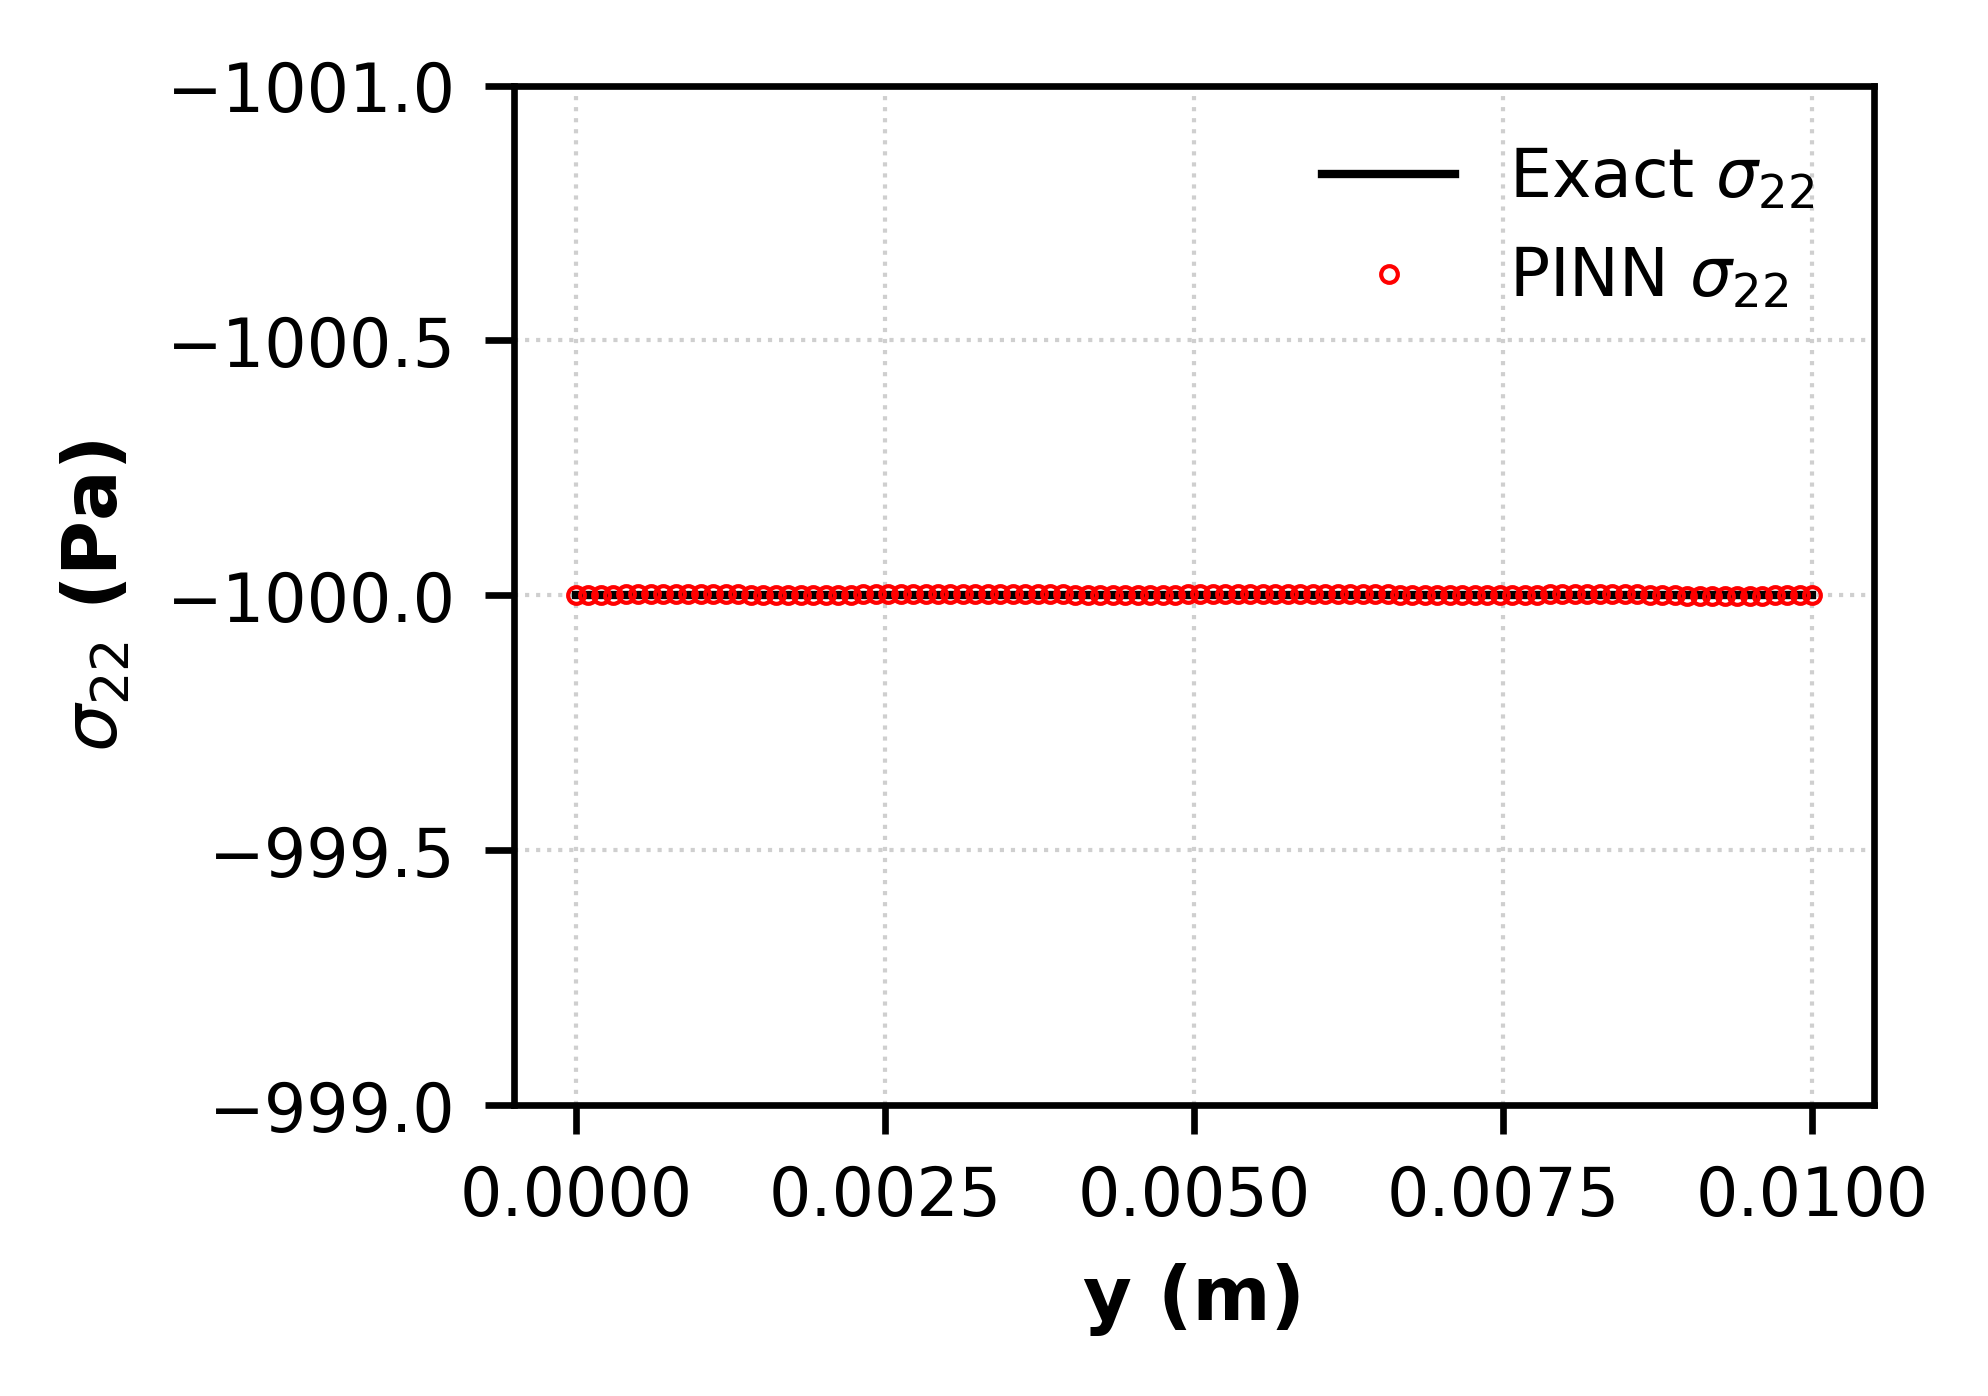

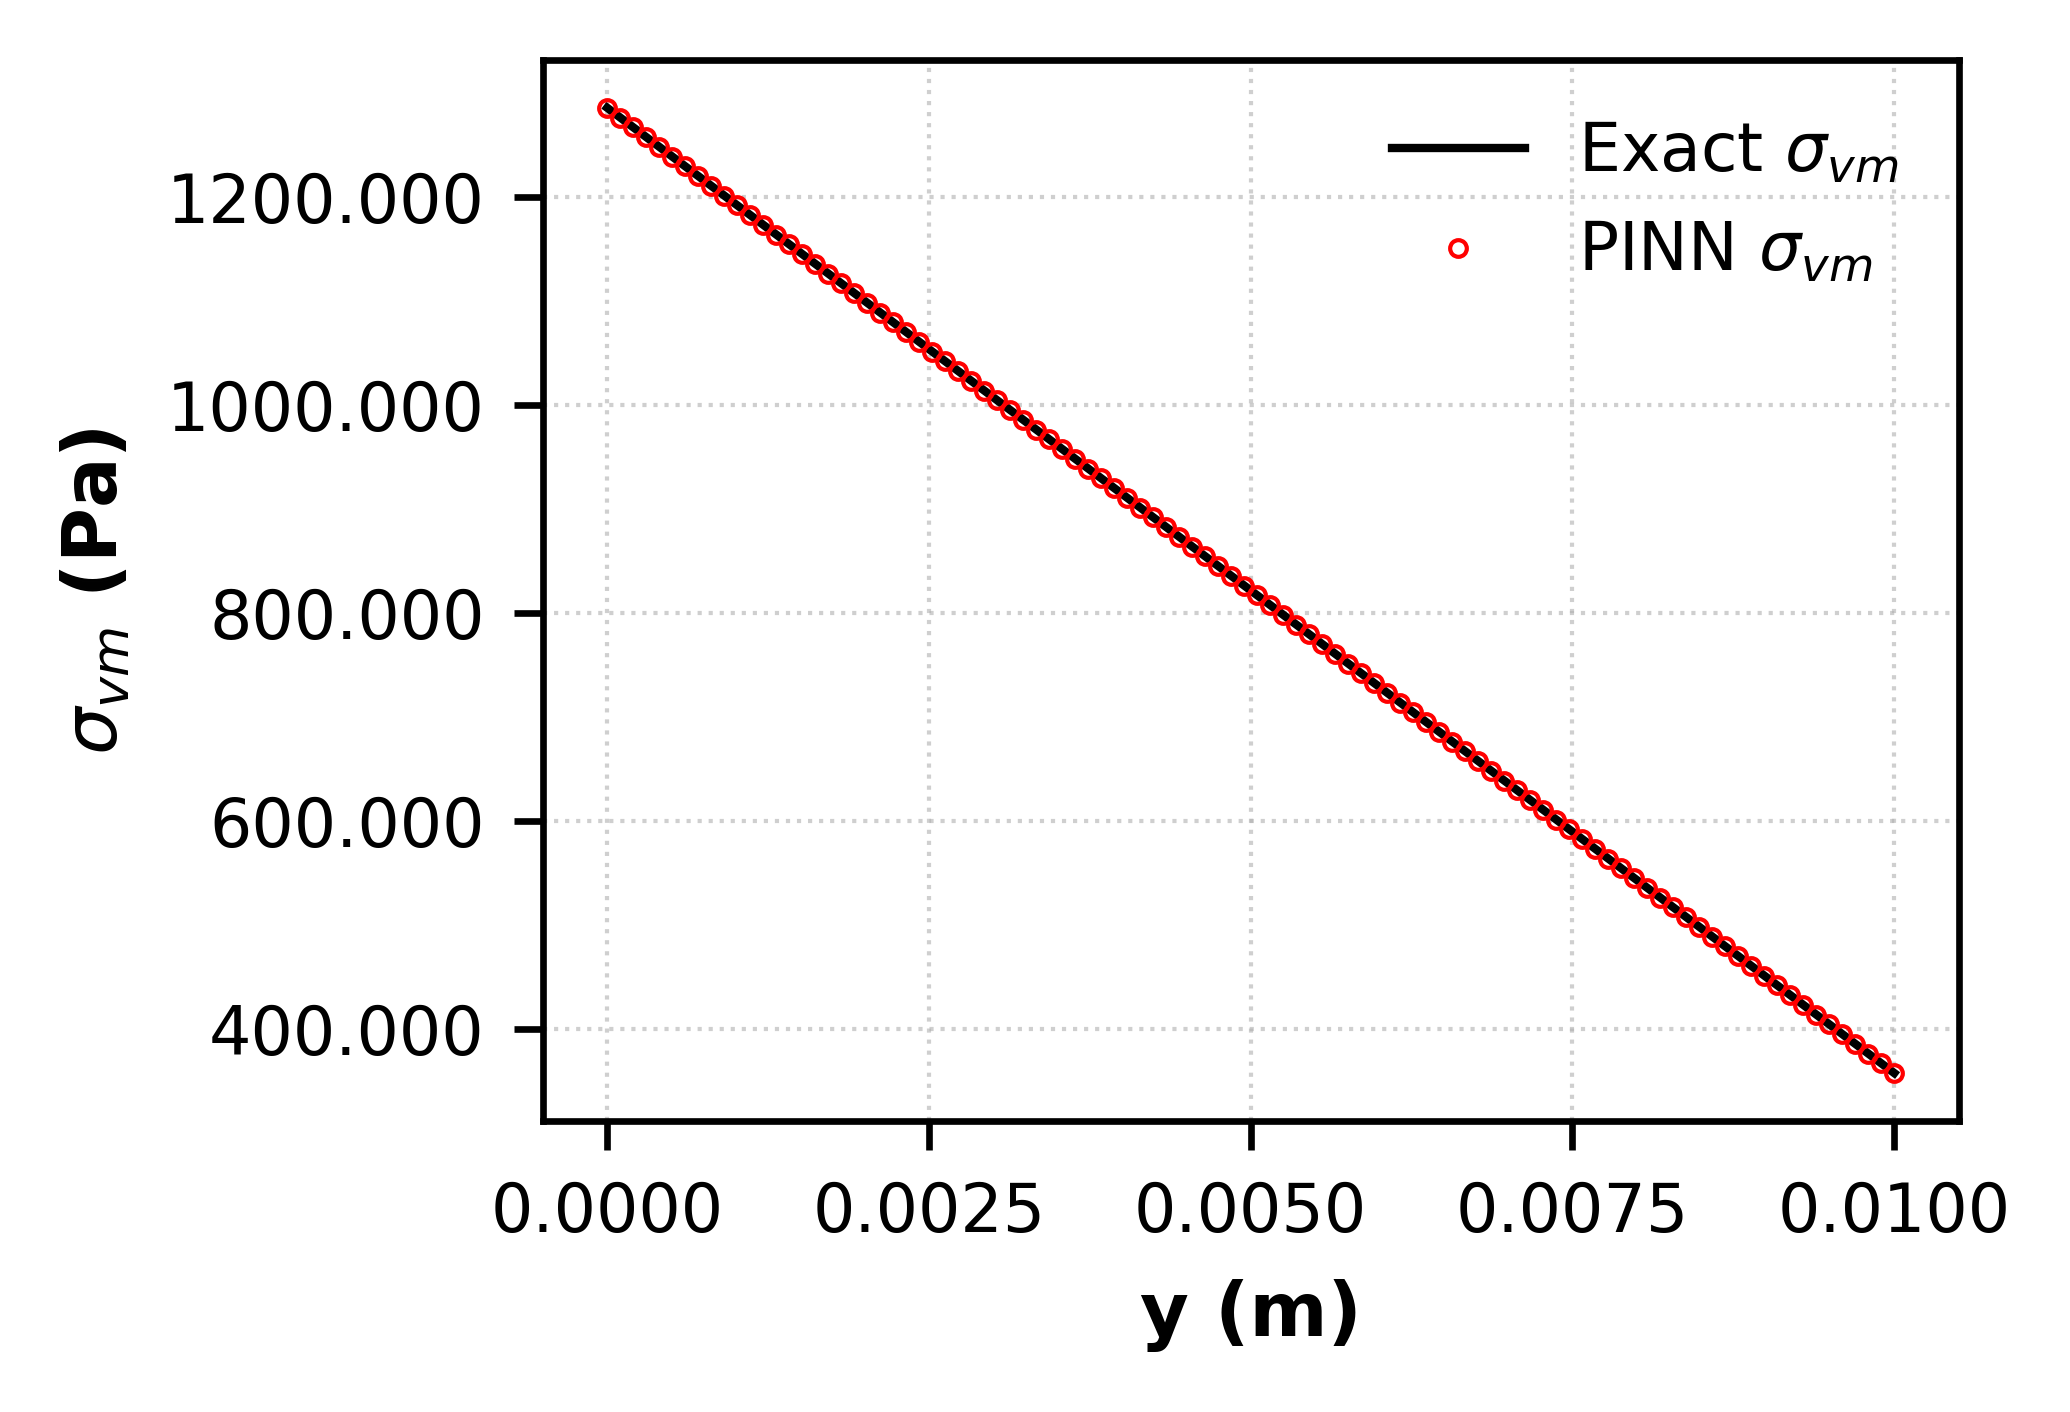

In [ ]:
# 7. Final Result Plot
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter

y_pts = np.linspace(0, h, 100)
x_pts = torch.tensor(np.stack([np.zeros(100), y_pts/h], axis=1))
with torch.no_grad():
    u2_pred = model(x_pts)[:, 1].numpy() * U_scale
u2_exact = ((-p_load*y_pts+beta*((T0-Tref)*y_pts-q/(2*k)*(y_pts)**2))/(2*mu+lam))

plt.figure(figsize=(3.5, 2.6), dpi=600)

plt.plot(y_pts,
         u2_exact,
         linestyle='-',
         linewidth=1,
         color='black',
         label='Exact $u_2$')

plt.plot(y_pts,
         u2_pred,
         linestyle='none',
         marker='o',
         markersize=2,
         markerfacecolor='none',
         markeredgewidth=0.5,
         color='red',
         label='PINN $u_2$')

plt.xlabel('y (m)', fontsize=9, fontweight='bold')
plt.ylabel('Displacement (m)', fontsize=9, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8, frameon=False)
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
plt.tight_layout()
ax = plt.gca()
ax.set_box_aspect(0.75)
plt.show()

# 1. Compute PINN Stress
x_pts.requires_grad_(True)
s11_p, s22_p, s33_p = compute_stress_pinn(x_pts)
vm_p_pts = torch.sqrt(0.5 * ((s11_p - s22_p)**2 + (s22_p - s33_p)**2 + (s33_p - s11_p)**2)).detach().numpy()



x_line = np.linspace(0, L, 100)
x_pts_length = torch.tensor(np.stack([x_line/L, np.ones(100)*0.5], axis=1), requires_grad=True)

s11_p_len, s22_p_len, _ = compute_stress_pinn(x_pts_length)
s11_e_len, s22_e_len, _ = exact_stress(x_pts_length)

s11_p_pts = s11_p_len.detach().numpy()
s11_e_pts = s11_e_len.detach().numpy()

plt.figure(figsize=(3.5, 2.6), dpi=600)
plt.plot(x_line, s11_e_pts, 'black', linewidth=1, label=r'Exact $\sigma_{11}$')
plt.plot(x_line, s11_p_pts, linestyle='none', marker='o', markersize=2,
         markerfacecolor='none', markeredgewidth=0.5, color='red', label=r'PINN $\sigma_{11}$')

plt.xlabel('x (m)', fontsize=9, fontweight='bold')
plt.ylabel(r'$\sigma_{11}$ (Pa)', fontsize=9, fontweight='bold')
plt.legend(fontsize=8, frameon=False)
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
plt.tight_layout()
exact_value = np.mean(s11_e_pts)
plt.ylim([exact_value - 0.0005*exact_value, exact_value + 0.0005*exact_value])
ax = plt.gca()
ax.set_box_aspect(0.75)
plt.show()

# --- 2. Compute Exact Stress ---
s11_e, s22_e, s33_e = exact_stress(x_pts)
vm_e_pts = torch.sqrt(0.5 * ((s11_e - s22_e)**2 + (s22_e - s33_e)**2 + (s33_e - s11_e)**2)).detach().numpy()
s11_p_pts=s11_p.detach().numpy()
s11_e_pts=s11_e.detach().numpy()

s22_p_pts=s22_p.detach().numpy()
s22_e_pts=s22_e.detach().numpy()

s33_p_pts=s33_p.detach().numpy()
s33_e_pts=s33_e.detach().numpy()


plt.figure(figsize=(3.5, 2.6), dpi=600)
plt.plot(y_pts, s22_e_pts, 'black', linewidth=1, label=r'Exact $\sigma_{22}$')
plt.plot(y_pts, s22_p_pts,linestyle='none', marker='o',
         markersize=2,
         markerfacecolor='none',
         markeredgewidth=0.5,
         color='red', label=r'PINN $\sigma_{22}$')


plt.xlabel('y (m)', fontsize=9, fontweight='bold')
plt.ylabel(r'$\sigma_{22}$ (Pa)', fontsize=9, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8, frameon=False)
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
plt.tight_layout()

exact_value = -p_load
plt.ylim([exact_value - 0.001*exact_value, exact_value + 0.001*exact_value])
ax = plt.gca()
ax.set_box_aspect(0.75)
plt.show()


plt.figure(figsize=(3.5, 2.6), dpi=600)
plt.plot(y_pts, vm_e_pts, 'black', linewidth=1, label=r'Exact $\sigma_{vm}$')
plt.plot(y_pts, vm_p_pts,linestyle='none', marker='o',
         markersize=2,
         markerfacecolor='none',
         markeredgewidth=0.5,
         color='red', label=r'PINN $\sigma_{vm}$')


plt.xlabel('y (m)', fontsize=9, fontweight='bold')
plt.ylabel(r'$\sigma_{vm}$ (Pa)', fontsize=9, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8, frameon=False)
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
plt.tight_layout()
ax = plt.gca()
ax.set_box_aspect(0.75)
plt.show()


target_pt = torch.tensor([[0.0, 0.5]], requires_grad=True)

with torch.no_grad():

    u2_p_val = (model(target_pt)[0, 1] * U_scale).item()
    u2_e_val = exact_solution(target_pt)[0, 1].item()
    u2_rel_err = abs(u2_p_val - u2_e_val) / (abs(u2_e_val) + 1e-20)

s11_p_val, s22_p_val, s33_p_val = compute_stress_pinn(target_pt)
s11_e_val, s22_e_val, s33_e_val = exact_stress(target_pt)

def calculate_standard_vm(s1, s2, s3):
    return torch.sqrt(0.5 * ((s1 - s2)**2 + (s2 - s3)**2 + (s3 - s1)**2)).item()


vm_p_val = calculate_standard_vm(s11_p_val, s22_p_val,s33_p_val)
vm_e_val = calculate_standard_vm(s11_e_val, s22_e_val, s33_e_val)
s22_rel_err = abs(s22_p_val.item() - s22_e_val.item()) / (abs(s22_e_val.item()) + 1e-20)
s11_rel_err = abs(s11_p_val.item() - s11_e_val.item()) / (abs(s11_e_val.item()) + 1e-20)
vm_rel_err = abs(vm_p_val - vm_e_val) / (abs(vm_e_val) + 1e-20)


In [ ]:
# Evaluate displacement fields
with torch.no_grad():
    u_pred = model(x_eval) * U_scale
    u_exact = exact_solution(x_eval)

u1_p = u_pred[:, 0].reshape(Nx_eval, Ny_eval).cpu().numpy()
u2_p = u_pred[:, 1].reshape(Nx_eval, Ny_eval).cpu().numpy()

u1_e = u_exact[:, 0].reshape(Nx_eval, Ny_eval).cpu().numpy()
u2_e = u_exact[:, 1].reshape(Nx_eval, Ny_eval).cpu().numpy()

X_plot = Xg.cpu().numpy()
Y_plot = Yg.cpu().numpy()


In [ ]:
# Evaluate stress fields
x_eval_grad = x_eval.clone().detach().requires_grad_(True)

s11_p, s22_p, s33_p = compute_stress_pinn(x_eval_grad)
s11_e, s22_e, s33_e = exact_stress(x_eval_grad)

def get_von_mises(s11, s22, s33):
    return torch.sqrt(0.5 * ((s11 - s22)**2 + (s22 - s33)**2 + (s33 - s11)**2))

vm_pred = get_von_mises(s11_p, s22_p, s33_p)
vm_exact = get_von_mises(s11_e, s22_e, s33_e)

s11_p = s11_p.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()
s22_p = s22_p.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()
s33_p = s33_p.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()


s11_e = s11_e.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()
s22_e = s22_e.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()
s33_e = s33_e.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()


vm_p = vm_pred.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()
vm_e = vm_exact.reshape(Nx_eval, Ny_eval).detach().cpu().numpy()

/tmp/ipykernel_11770/3806270921.py:11: UserWarning: The following kwargs were not used by contour: 'shading'
  cf = plt.contourf(X, Y, data, levels=levels, cmap='viridis', shading='gouraud', vmin=vmin, vmax=vmax)


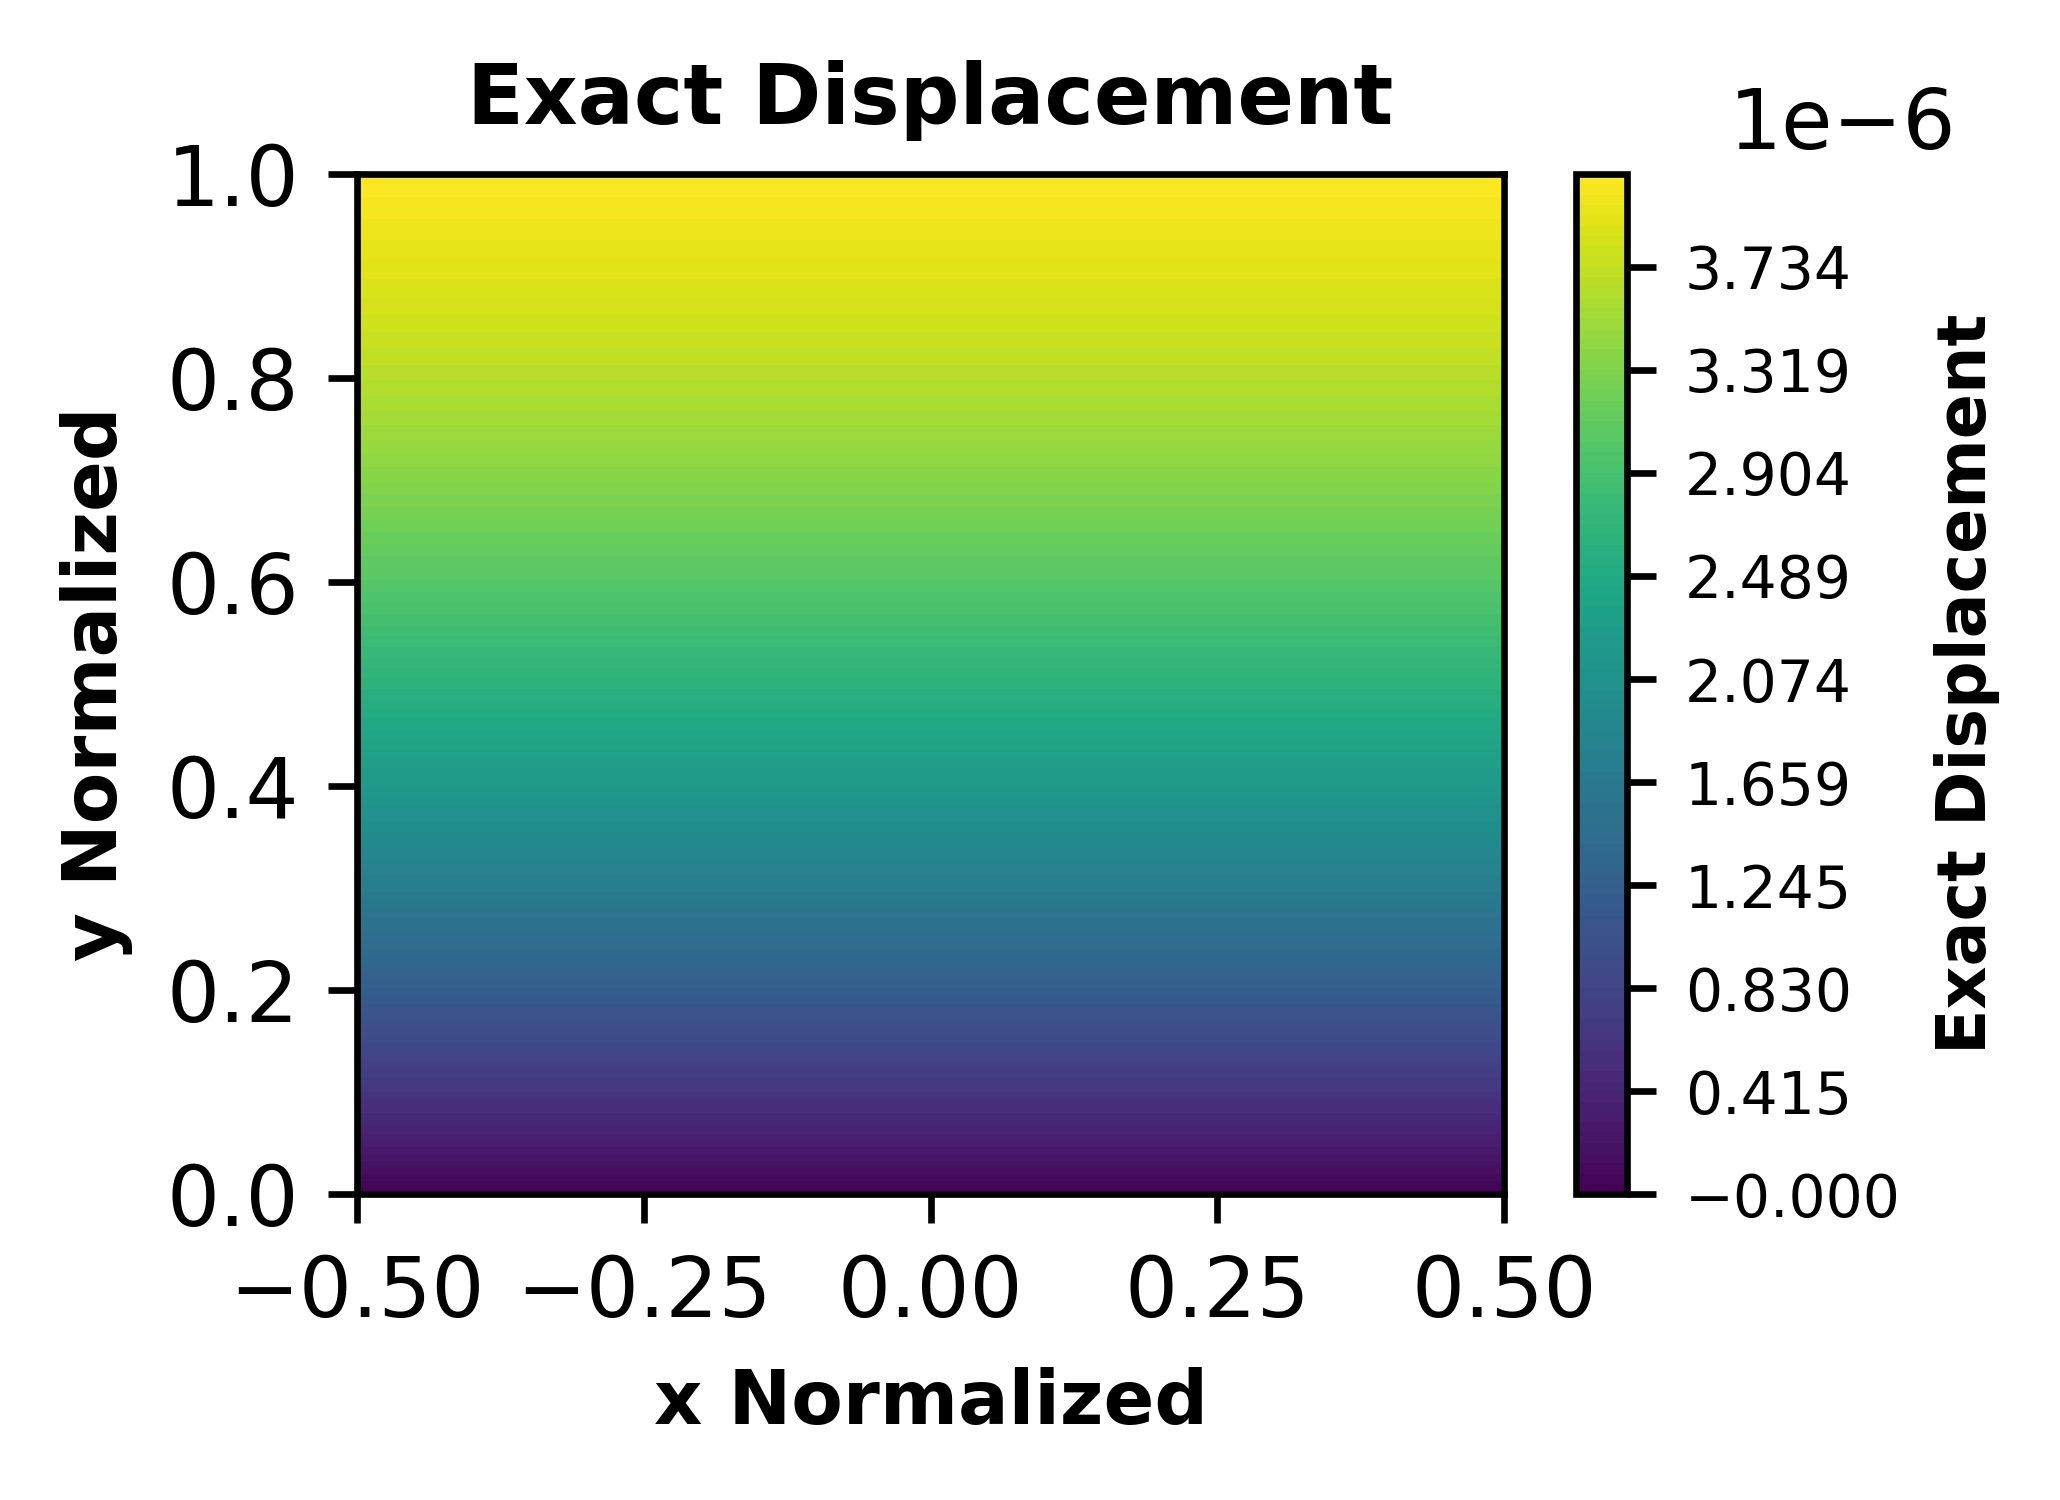

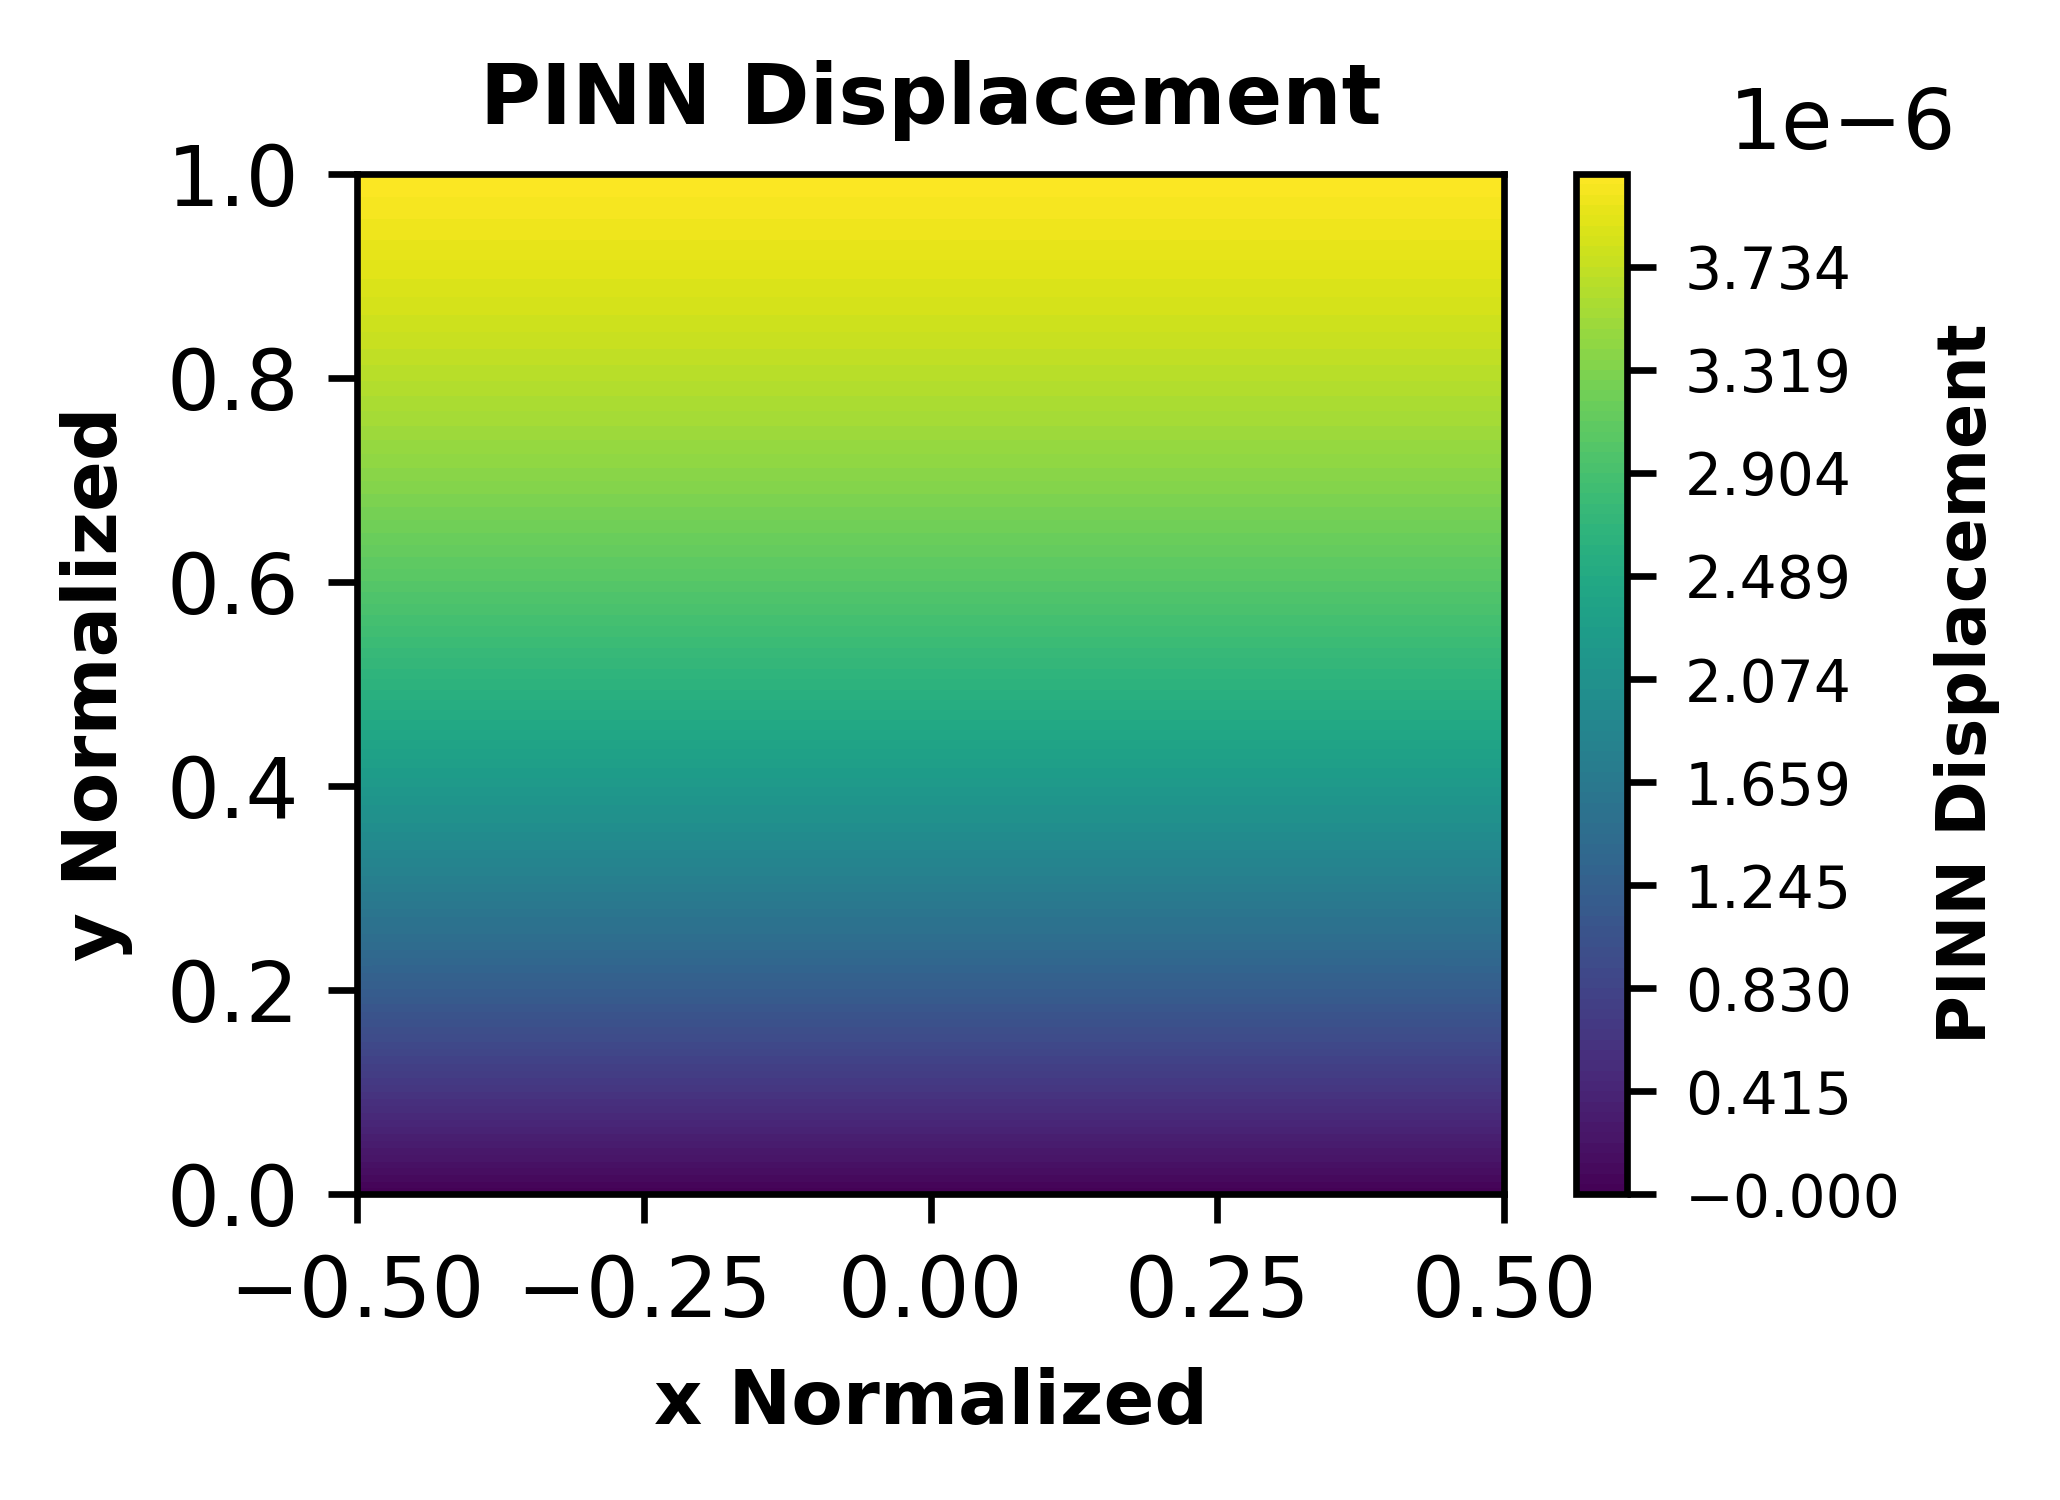

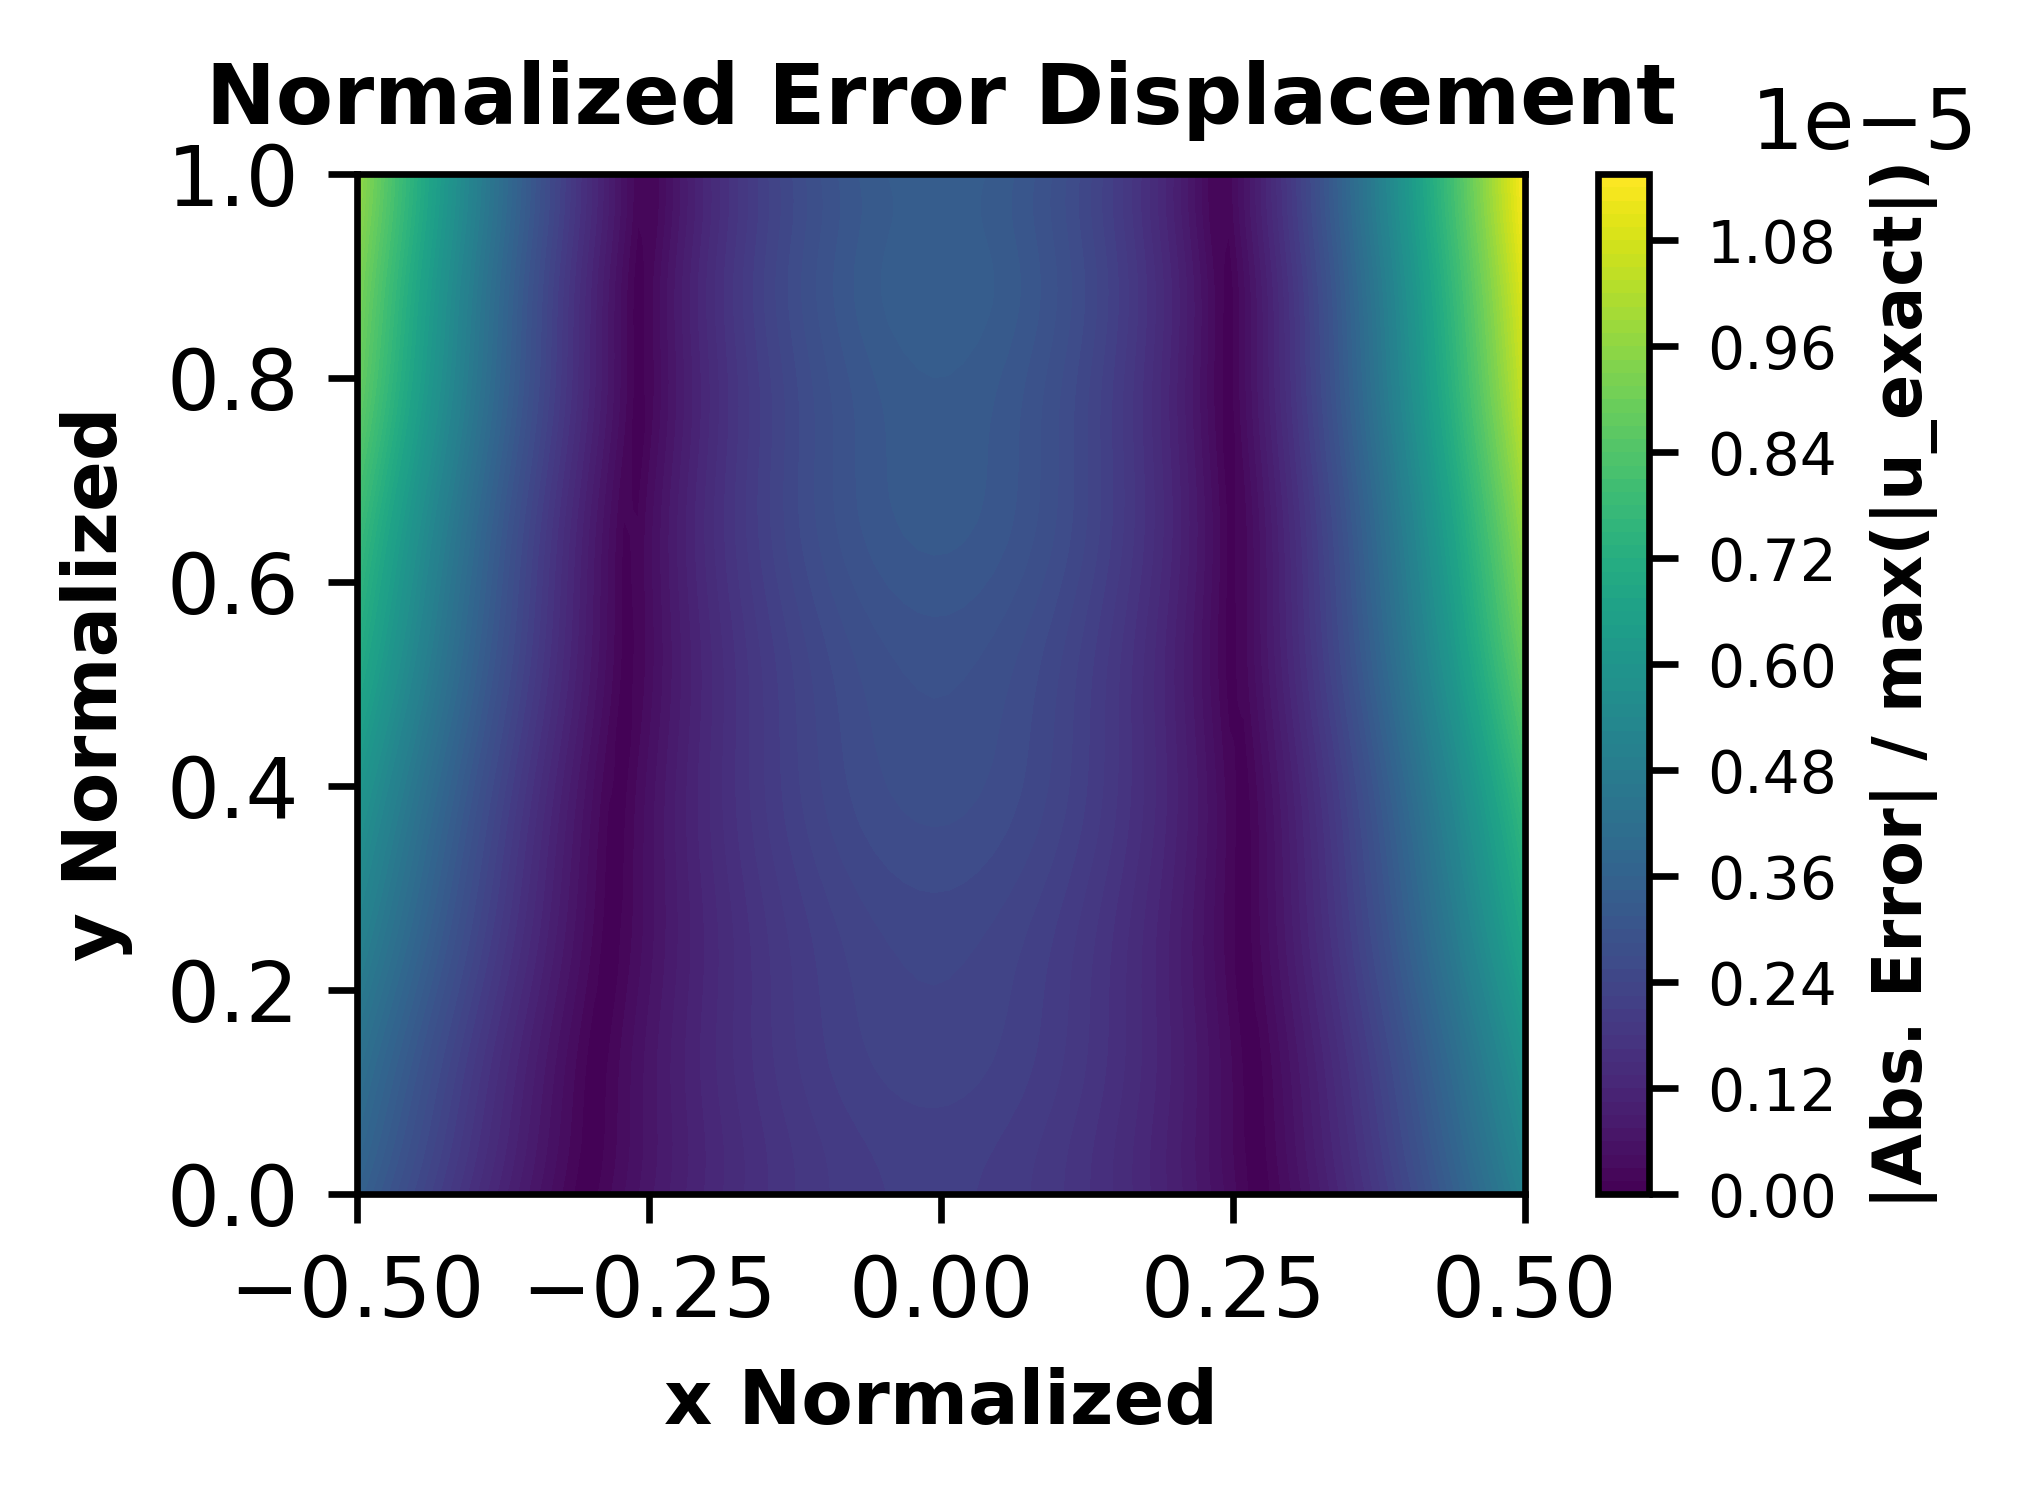

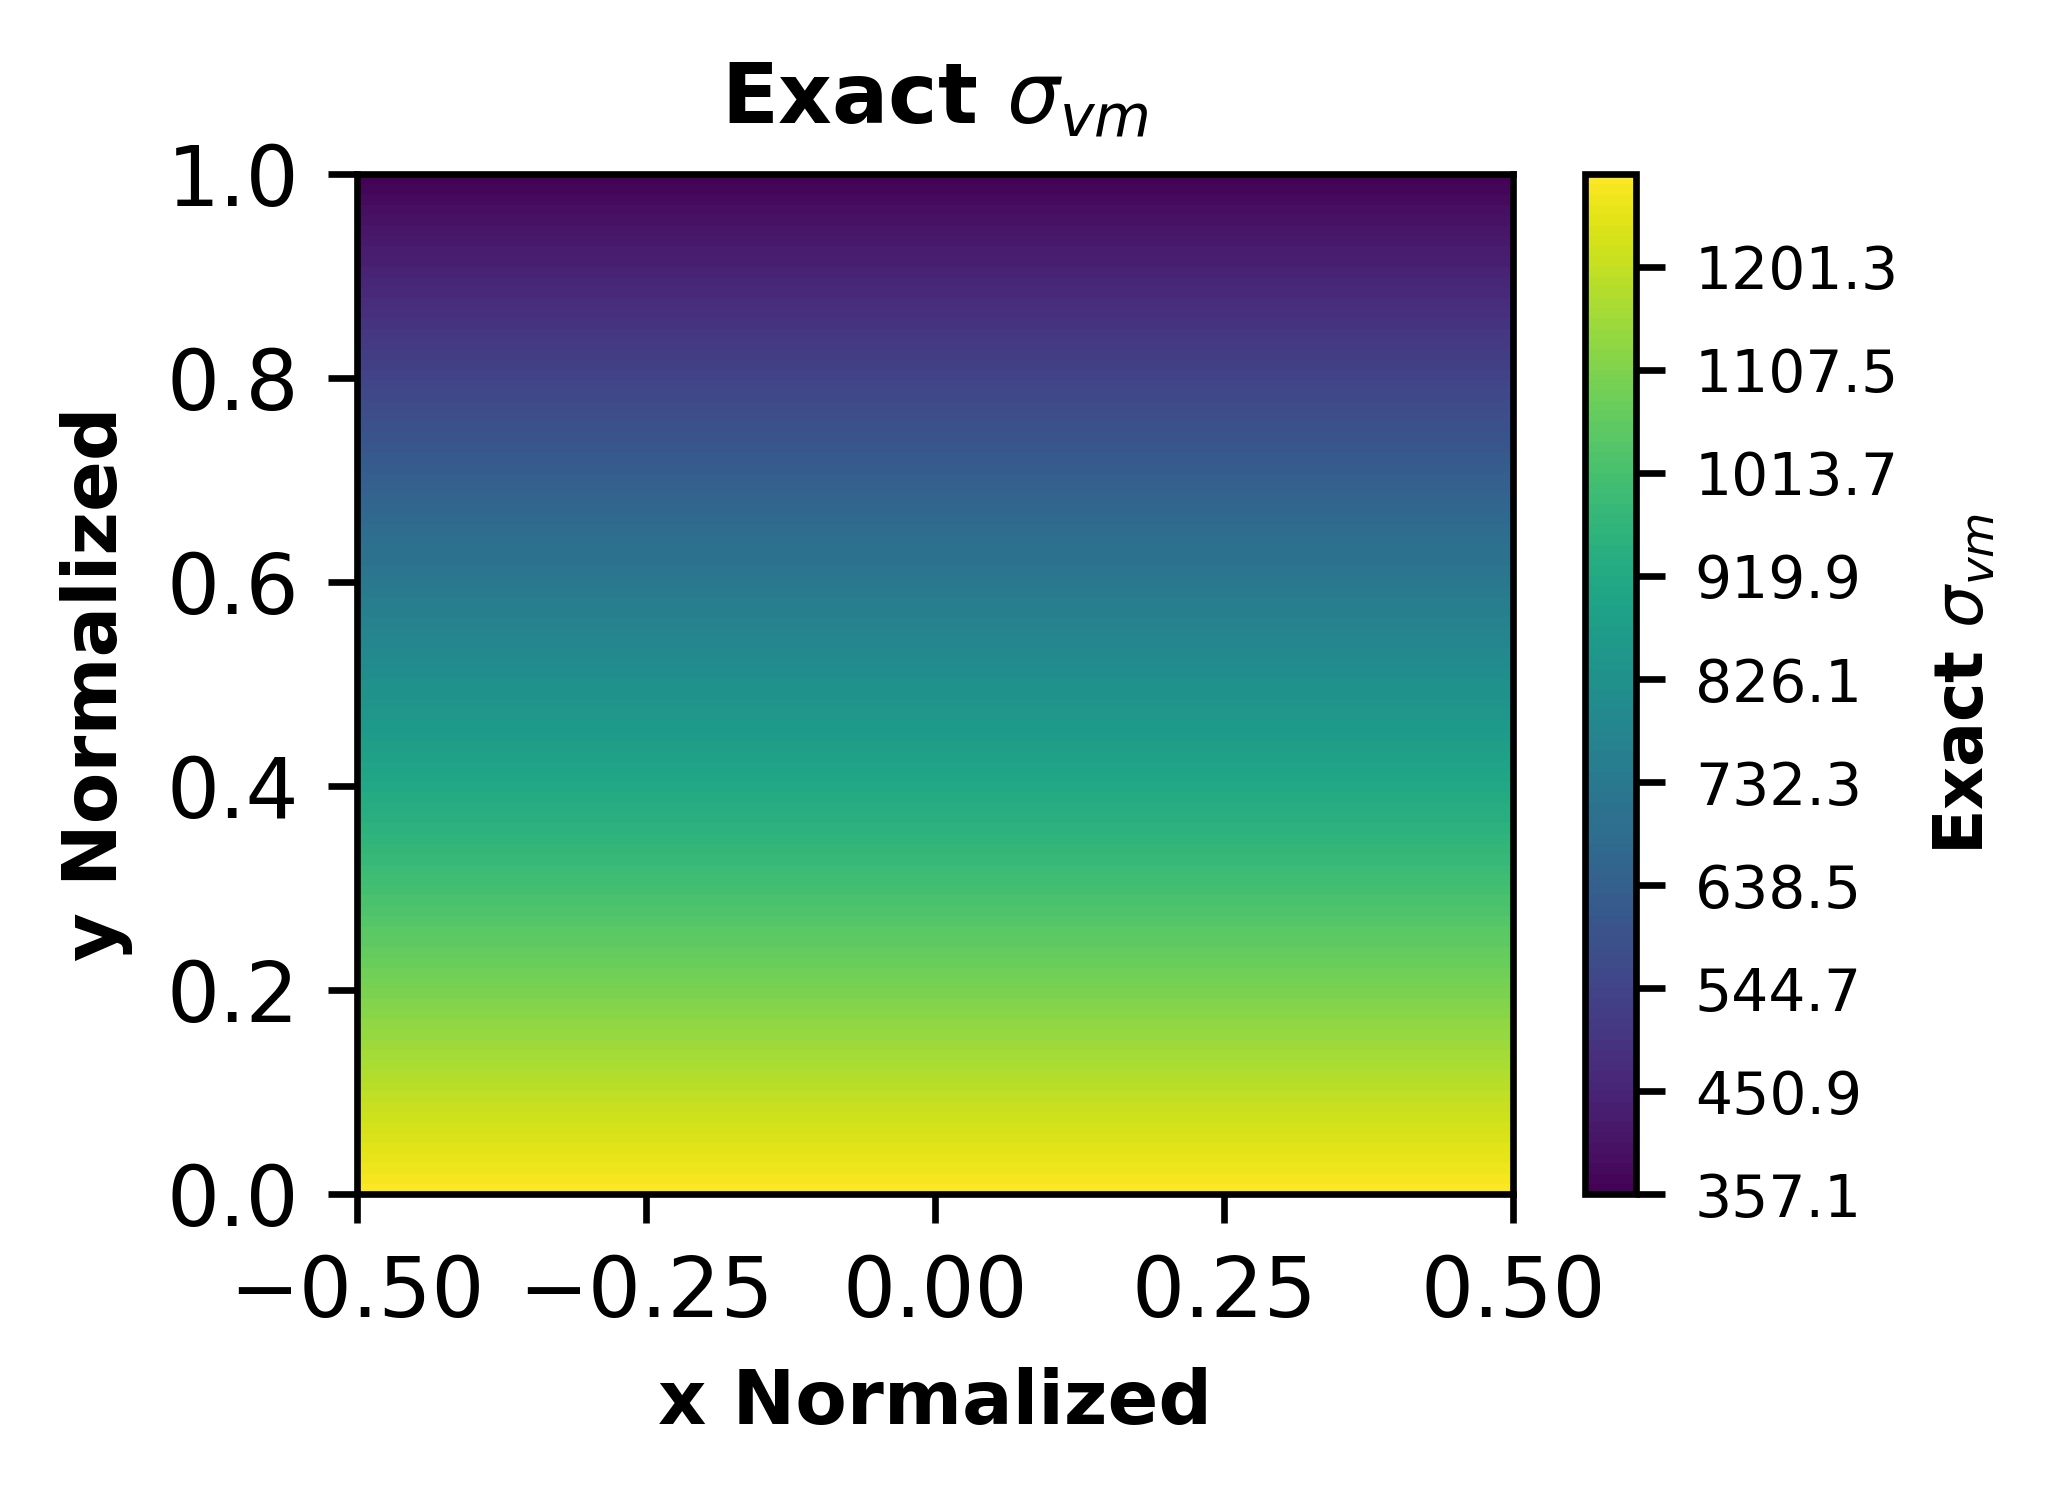

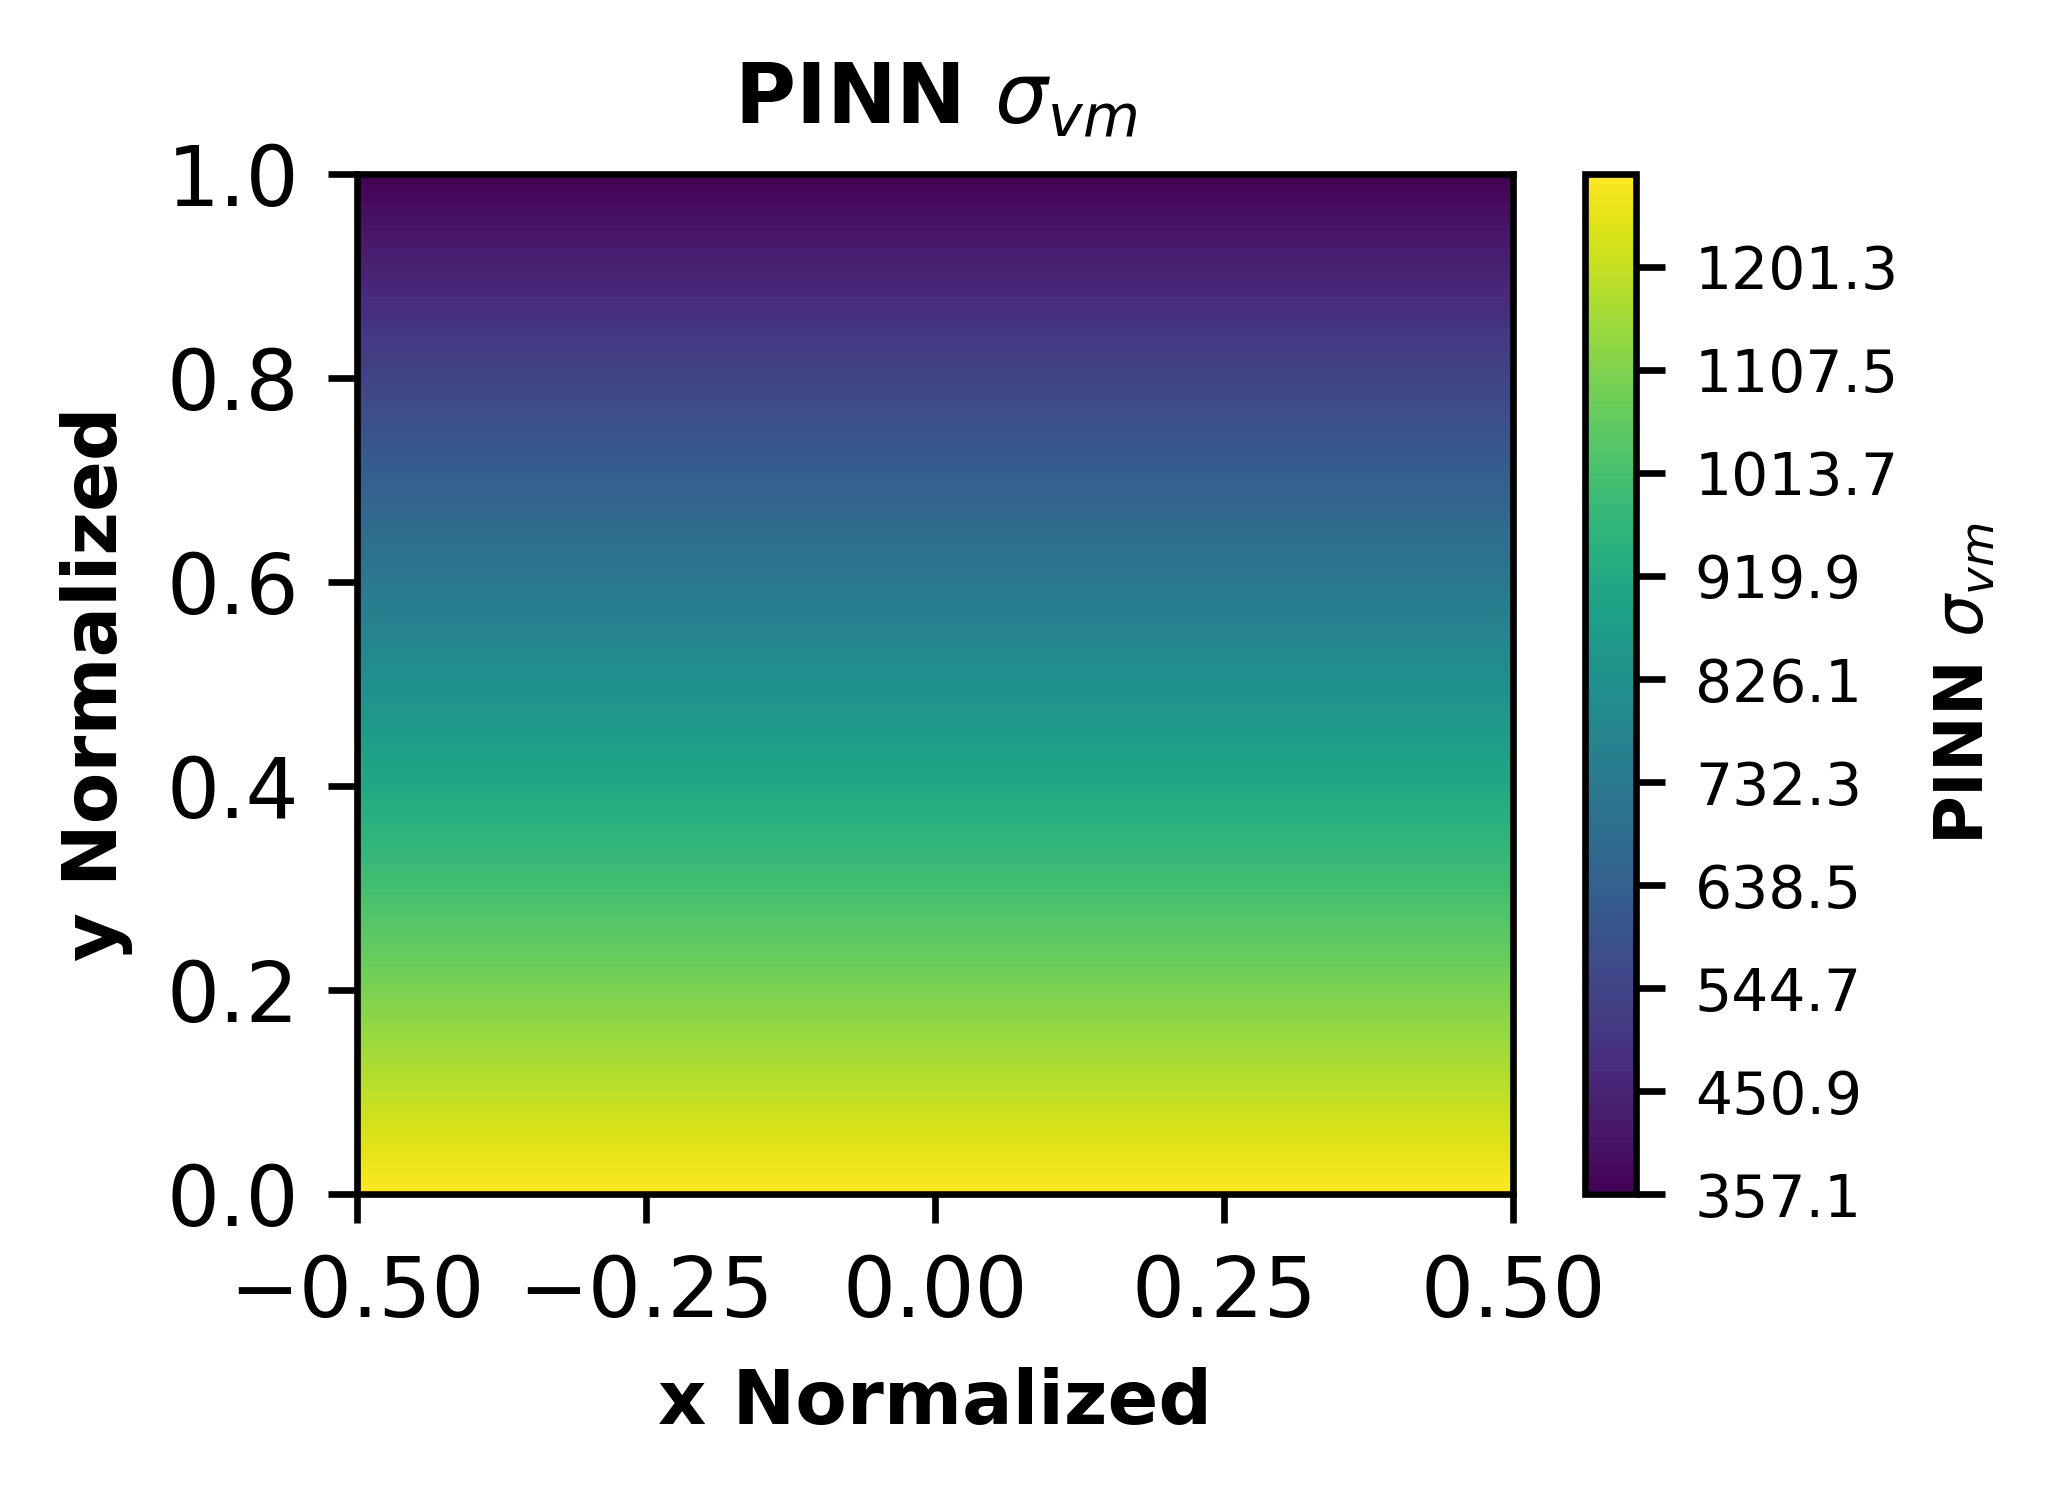

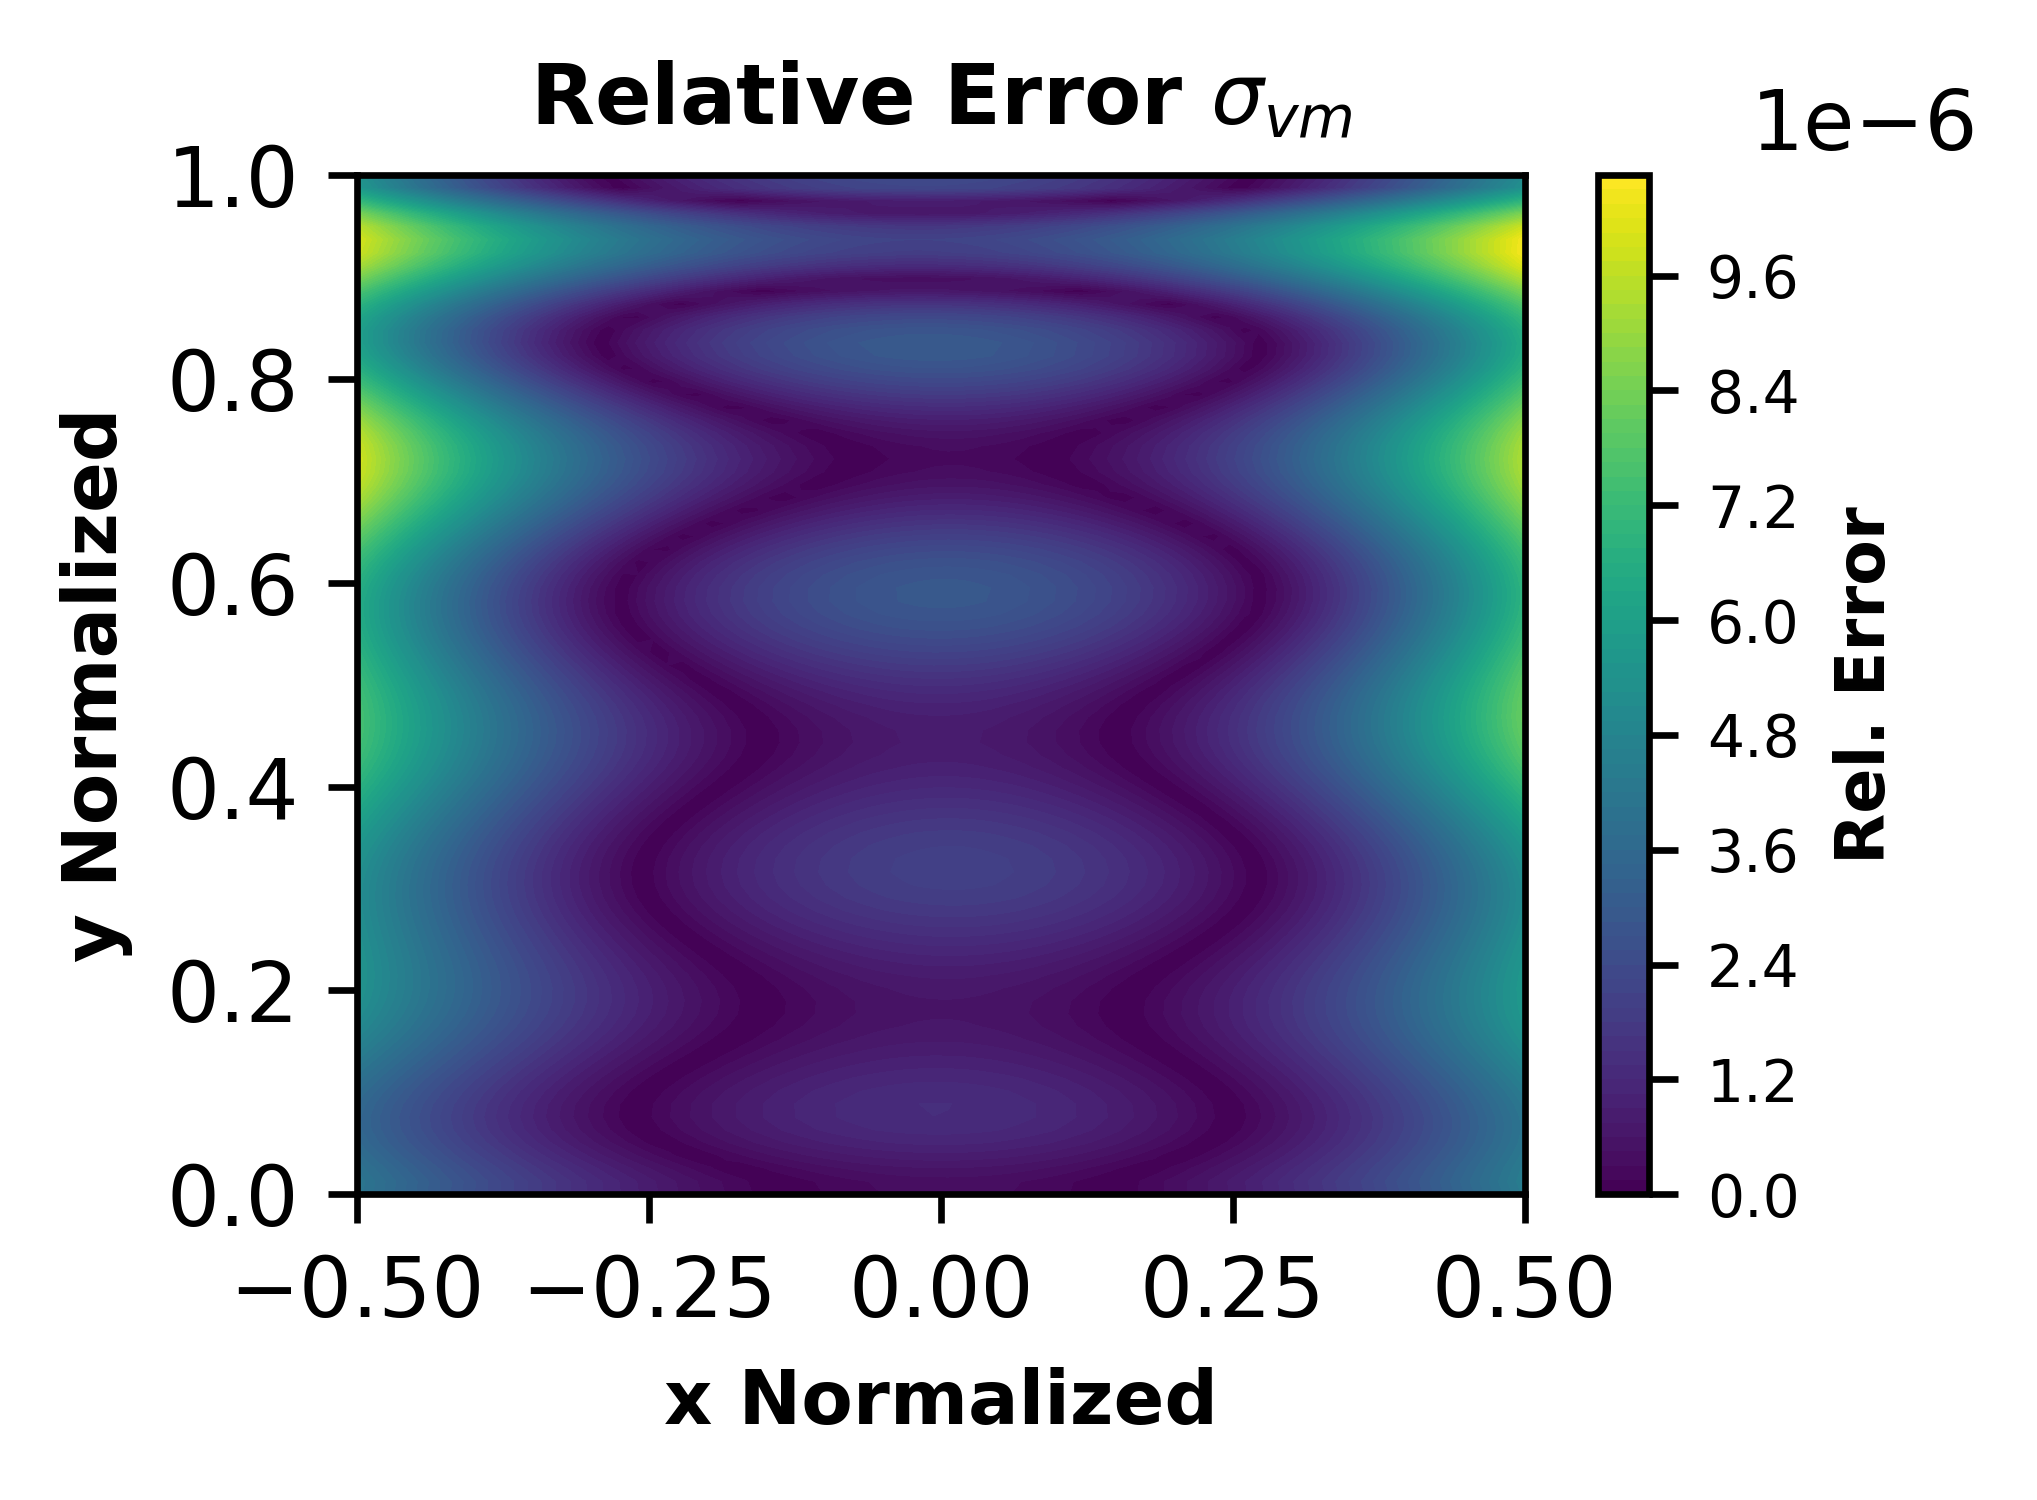

In [ ]:

def compare_fields_relative(X, Y, exact, pred, title):
    epsilon = 1e-20

    vmin = min(exact.min(), pred.min())
    vmax = max(exact.max(), pred.max())

    levels = np.linspace(vmin, vmax, 100) if vmin != vmax else 50

    for i, (data, plot_title) in enumerate(zip([exact, pred], [f"Exact {title}", f"PINN {title}"])):
        plt.figure(figsize=(3.5, 2.6), dpi=600)
        cf = plt.contourf(X, Y, data, levels=levels, cmap='viridis', shading='gouraud', vmin=vmin, vmax=vmax)
        cbar = plt.colorbar(cf)

        if "stress" in title.lower():
            cbar.formatter.set_scientific(False)
            cbar.formatter.set_useOffset(False)
            cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
        else:
            cbar.ax.yaxis.get_offset_text().set_position((3.0, 1.05))
            cbar.ax.yaxis.get_offset_text().set_horizontalalignment('left')

        cbar.set_label(plot_title, fontsize=8, fontweight='bold')
        cbar.set_label(plot_title, fontsize=8)
        cbar.ax.tick_params(labelsize=7)
        plt.xlabel(r'x Normalized', fontsize=9, fontweight='bold')
        plt.ylabel(r'y Normalized', fontsize=9, fontweight='bold')
        plt.title(plot_title, fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()

    if "displacement" in title.lower():
        u_max_global = np.max(np.abs(exact)) + 1e-25
        error_data = np.abs(pred - exact) / u_max_global
        error_title = f"Normalized Error {title}"
        error_label = "|Abs. Error| / max(|u_exact|)"
    else:
        error_data = np.abs(pred - exact) / (np.abs(exact) + epsilon)
        error_title = f"Relative Error {title}"
        error_label = "Rel. Error"

    plt.figure(figsize=(3.5, 2.6), dpi=600)
    cf = plt.contourf(X, Y, error_data, levels=100, cmap='viridis')
    cbar = plt.colorbar(cf)

    cbar.ax.yaxis.get_offset_text().set_position((3.0, 1.05))
    cbar.ax.yaxis.get_offset_text().set_horizontalalignment('left')
    cbar.update_ticks()

    cbar.set_label(error_label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label(error_label, fontsize=8, fontweight='bold')
    plt.xlabel(r'x Normalized', fontsize=9, fontweight='bold')
    plt.ylabel(r'y Normalized', fontsize=9, fontweight='bold')
    plt.title(error_title, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()
compare_fields_relative(X_plot, Y_plot, u2_e, u2_p, "Displacement")
compare_fields_relative(X_plot, Y_plot, vm_e, vm_p, r'$\sigma_{vm}$')